# Measured neutron data analysis — compact workflow

This notebook processes the neutron measurements recorded with the
Studsvik AE 2202 D around the moderated Am--Be source. It has one
purpose: create a clean, background-corrected and geometry-ready
measured-neutron dataset for Notebook 5.

The reported experimental quantity is the Studsvik-indicated neutron
dose-equivalent rate,

$$
\dot H_{n,\mathrm{2202D,ind}}
\quad [\mu\mathrm{Sv/h}].
$$

It is an instrument indication, not a direct neutron-flux measurement
and not an ICRP-116 AP effective-dose-rate estimate. Simulation-to-
measurement comparisons are therefore deferred to Notebook 6.

The required input folders are:

```text
neutron_logs_baggrund
neutron_logs_P1
neutron_logs_P2
neutron_logs_P3
neutron_logs_P4
neutron_logs_P5
```

Each CSV may contain the columns shown by the logger,
`timestamp, raw, mrem/h, tail, dt_s`. The numerical `mrem/h` column is
preferred; the hexadecimal field in `raw` is decoded as a consistency
check. Repeated files at the same nominal position are consolidated
before the selected local background is subtracted.

## Workflow

1. Read and validate all neutron CSV files.
2. Consolidate repeats and subtract the local third-floor background.
3. Propagate within-file, repeatability and background uncertainties.
4. Insert P1--P5 points into the shared geometry.
5. Export the canonical tables immediately.
6. Produce and save the principal plots.


In [2]:
# 1) Setup, paths and physical conventions

from pathlib import Path
from itertools import combinations
import importlib
import json
import re

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, to_rgb
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
import numpy as np
import pandas as pd

try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value)


def find_project_root(start):
    """Find the nearest folder containing the neutron-log folders."""
    start = Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "neutron_logs_P1").is_dir():
            return candidate
    return start


BASE_DIR = find_project_root(Path.cwd())
LOG_FOLDERS = {
    "background": BASE_DIR / "neutron_logs_baggrund",
    **{
        position: BASE_DIR / f"neutron_logs_{position}"
        for position in ["P1", "P2", "P3", "P4", "P5"]
    },
}

OUTPUT_DIR = BASE_DIR / "N4_measured_neutron_outputs"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
METADATA_DIR = OUTPUT_DIR / "metadata"
for folder in (TABLE_DIR, FIGURE_DIR, METADATA_DIR):
    folder.mkdir(parents=True, exist_ok=True)

POSITION_SEQUENCE = ["P1", "P2", "P3", "P4", "P5"]
POSITION_ORDER = {position: index for index, position in enumerate(POSITION_SEQUENCE)}
POSITION_COLORS = {
    "P1": "tab:blue",
    "P2": "tab:orange",
    "P3": "tab:green",
    "P4": "tab:red",
    "P5": "tab:purple",
}
DIRECTION_COLOURS = POSITION_COLORS


def lighten_color(color, amount):
    """Blend a Matplotlib colour toward white by ``amount``."""
    base_rgb = np.asarray(to_rgb(color), dtype=float)
    white_rgb = np.ones(3)
    return tuple((1.0 - amount) * base_rgb + amount * white_rgb)


def make_position_height_colors(dataframe):
    """Use one base colour per P direction and a shade per real height."""
    colour_map = {}
    for position in POSITION_SEQUENCE:
        heights = np.sort(
            dataframe.loc[dataframe["position"] == position, "height_cm"]
            .dropna().astype(float).unique()
        )
        if len(heights) == 0:
            continue
        lightening_amounts = (
            np.array([0.0])
            if len(heights) == 1
            else np.linspace(0.0, 0.48, len(heights))
        )
        for height_cm, amount in zip(heights, lightening_amounts):
            colour_map[(position, float(height_cm))] = lighten_color(
                POSITION_COLORS[position], amount
            )
    return colour_map

MREM_H_TO_USV_H = 10.0
LOCAL_BACKGROUND_LOCATION = "3_sal_gang"

STUDSVIK_MANUFACTURER = "AB Atomenergi Sweden (Studsvik)"
STUDSVIK_MODEL = "AE 2202 D"
STUDSVIK_HEAD_DIAMETER_CM = 21.5
STUDSVIK_ACTIVE_REFERENCE_OFFSET_CM = STUDSVIK_HEAD_DIAMETER_CM / 2.0
STUDSVIK_MEASUREMENT_ORIENTATION_DEG = 90.0
STUDSVIK_ORIENTATION_UNCERTAINTY_DEG = 1.0
STUDSVIK_NOMINAL_SENSITIVITY_CPS_PER_MREM_H = 3.6
MEASUREMENT_POSITION_UNCERTAINTY_CM = 1.0
MEASUREMENT_QUANTITY = (
    "Studsvik AE 2202 D indicated neutron dose-equivalent rate"
)
MEASUREMENT_QUANTITY_SYMBOL = "Hdot_n_2202D_ind"
AP_EFFECTIVE_DOSE_EQUIVALENCE_ASSUMED = False

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 9,
    "legend.title_fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

print(f"Project folder: {BASE_DIR}")
print(f"Output folder:  {OUTPUT_DIR}")
print("Output folders were created before any analysis is run.")


Project folder: /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn
Output folder:  /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N4_measured_neutron_outputs
Output folders were created before any analysis is run.


# 2) Filename and CSV decoding

Scan filenames use the convention
`NF_P1_x_0_y_42_10_min.csv`, where `x` is the measured line
distance from the cabinet reference and `y` is the detector height
above the cabinet bottom. Labels such as `SHORT`, `LONG`, replicate
numbers and `24h` do not create new physical points.

The AE 2202 D raw field has the form `J3<hex>J...`; for example,
`J336J40` contains hexadecimal `36`, corresponding to $54\ \mathrm{mrem/h}$.


In [3]:
# Filename parsing and robust CSV reader

def normalized_stem(path):
    text = Path(path).stem.strip().casefold()
    text = text.replace("–", "-").replace("—", "-")
    text = re.sub(r"[\s-]+", "_", text)
    return re.sub(r"_+", "_", text).strip("_")


def parse_number(token):
    return float(str(token).replace(",", ".").replace("p", "."))


def coordinate_token(value):
    value = float(value)
    return str(int(value)) if value.is_integer() else f"{value:g}"


def duration_from_stem(stem):
    is_24h = bool(re.search(r"(?:^|_)24_?h(?:_|$)", stem))
    matches = re.findall(r"(?:^|_)(\d+(?:[.,p]\d+)?)_min(?:_|$)", stem)
    duration_token = parse_number(matches[-1]) if matches else np.nan
    return (24.0 * 60.0 if is_24h else duration_token), is_24h


def parse_measurement_filename(path, folder_position):
    stem = normalized_stem(path)
    duration_min, is_24h = duration_from_stem(stem)

    scan_match = re.search(
        r"(?:^|_)p(?P<position>[1-5])_x_(?P<distance>\d+(?:[.,p]\d+)?)"
        r"_y_(?P<height>\d+(?:[.,p]\d+)?)(?:_|$)",
        stem,
    )
    if scan_match:
        position = f"P{scan_match.group('position')}"
        if folder_position != position:
            raise ValueError(
                f"Filename says {position}, but file is in {folder_position}."
            )
        distance_cm = parse_number(scan_match.group("distance"))
        height_cm = parse_number(scan_match.group("height"))
        point_id = (
            f"{position}_x{coordinate_token(distance_cm)}"
            f"_h{coordinate_token(height_cm)}"
        )
        replicate_match = re.search(r"_min_(\d+)(?:_|$)", stem)
        return {
            "measurement_kind": "scan",
            "position": position,
            "distance_cm": distance_cm,
            "height_cm": height_cm,
            "location_label": pd.NA,
            "physical_point_id": point_id,
            "duration_min": duration_min,
            "is_24h_measurement": is_24h,
            "replicate_label": (
                replicate_match.group(1) if replicate_match else pd.NA
            ),
            "is_short_measurement": "short" in stem,
            "is_long_measurement": "long" in stem,
        }

    background_match = re.search(r"(?:^|_)p6_(?P<body>.+)$", stem)
    if background_match and folder_position == "background":
        body = background_match.group("body")
        duration_match = re.search(
            r"_(?:\d+(?:[.,p]\d+)?)_(?:24h_)?min(?:_|$)", body
        )
        location = body[:duration_match.start()] if duration_match else body
        location = re.sub(
            r"_(?:mrem|short|long|24h|\d+)$", "", location
        ).strip("_")
        if not location:
            raise ValueError("The background location label is empty.")
        return {
            "measurement_kind": "background",
            "position": "background",
            "distance_cm": np.nan,
            "height_cm": np.nan,
            "location_label": location,
            "physical_point_id": f"background_{location}",
            "duration_min": duration_min,
            "is_24h_measurement": is_24h,
            "replicate_label": pd.NA,
            "is_short_measurement": "short" in stem,
            "is_long_measurement": "long" in stem,
        }

    raise ValueError(f"Unrecognized measurement filename: {Path(path).name}")


def normalized_column_name(name):
    text = str(name).strip().casefold().replace("µ", "u")
    return re.sub(r"[^a-z0-9]+", "_", text).strip("_")


def find_column(dataframe, candidates):
    lookup = {normalized_column_name(column): column for column in dataframe.columns}
    for candidate in candidates:
        found = lookup.get(normalized_column_name(candidate))
        if found is not None:
            return found
    return None


def decode_raw_to_mrem_h(raw_value):
    if pd.isna(raw_value):
        return np.nan
    match = re.search(r"J3([0-9A-Fa-f]+)J", str(raw_value))
    if not match:
        return np.nan
    try:
        return float(int(match.group(1), 16))
    except ValueError:
        return np.nan


def read_csv_robust(path):
    attempts = [
        {},
        {"sep": None, "engine": "python"},
        {"sep": ";"},
        {"sep": "\t"},
    ]
    last_error = None
    for kwargs in attempts:
        try:
            dataframe = pd.read_csv(path, **kwargs)
            if dataframe.shape[1] > 1 or kwargs == attempts[-1]:
                return dataframe
        except Exception as error:
            last_error = error
    raise ValueError(f"Could not read {Path(path).name}: {last_error}")


def summarize_measurement_file(path, metadata):
    dataframe = read_csv_robust(path)
    mrem_column = find_column(
        dataframe,
        ["mrem/h", "mrem_h", "mrem", "dose_rate_mrem_h"],
    )
    raw_column = find_column(dataframe, ["raw", "raw_data", "raw_value"])
    if mrem_column is None and raw_column is None:
        raise ValueError(
            f"{Path(path).name} has neither a numerical mrem/h column "
            "nor a raw AE 2202 D column."
        )

    numerical = (
        pd.to_numeric(dataframe[mrem_column], errors="coerce")
        if mrem_column is not None else None
    )
    decoded = (
        dataframe[raw_column].map(decode_raw_to_mrem_h)
        if raw_column is not None else None
    )
    values = numerical if numerical is not None else decoded
    values = pd.to_numeric(values, errors="coerce")
    valid = np.isfinite(values) & (values >= 0.0)
    valid_values = values.loc[valid].astype(float)
    if valid_values.empty:
        raise ValueError(f"{Path(path).name} contains no valid dose-rate readings.")

    overlap = (
        numerical.notna() & decoded.notna()
        if numerical is not None and decoded is not None
        else pd.Series(False, index=dataframe.index)
    )
    mismatch_count = int(
        (~np.isclose(
            numerical.loc[overlap], decoded.loc[overlap],
            rtol=0.0, atol=1.0e-12,
        )).sum()
    ) if overlap.any() else 0

    n = int(valid_values.size)
    std_mrem_h = float(valid_values.std(ddof=1)) if n > 1 else 0.0
    sem_mrem_h = std_mrem_h / np.sqrt(n)
    timestamp_column = find_column(dataframe, ["timestamp", "time", "datetime"])
    timestamps = (
        pd.to_datetime(dataframe[timestamp_column], errors="coerce")
        if timestamp_column is not None else pd.Series(dtype="datetime64[ns]")
    )
    dt_column = find_column(dataframe, ["dt_s", "delta_t_s"])
    observed_duration_s = (
        float(pd.to_numeric(dataframe[dt_column], errors="coerce").sum())
        if dt_column is not None else np.nan
    )

    result = dict(metadata)
    result.update({
        "file": str(Path(path).resolve()),
        "file_name": Path(path).name,
        "input_format": (
            "numerical_mrem_h_with_raw_check"
            if numerical is not None and decoded is not None
            else "numerical_mrem_h" if numerical is not None
            else "decoded_raw"
        ),
        "source_column": mrem_column if mrem_column is not None else raw_column,
        "original_rows": int(len(dataframe)),
        "valid_rows": n,
        "invalid_rows": int(len(dataframe) - n),
        "valid_fraction": float(n / len(dataframe)),
        "raw_numeric_mismatch_count": mismatch_count,
        "observed_duration_s": observed_duration_s,
        "start_timestamp": timestamps.min() if not timestamps.empty else pd.NaT,
        "end_timestamp": timestamps.max() if not timestamps.empty else pd.NaT,
        "mean_mrem_h": float(valid_values.mean()),
        "median_mrem_h": float(valid_values.median()),
        "std_mrem_h": std_mrem_h,
        "sem_mrem_h": sem_mrem_h,
        "min_mrem_h": float(valid_values.min()),
        "max_mrem_h": float(valid_values.max()),
        "mean_uSv_h": float(valid_values.mean() * MREM_H_TO_USV_H),
        "median_uSv_h": float(valid_values.median() * MREM_H_TO_USV_H),
        "std_uSv_h": float(std_mrem_h * MREM_H_TO_USV_H),
        "sem_uSv_h": float(sem_mrem_h * MREM_H_TO_USV_H),
    })
    result["file_quality_status"] = (
        "review_required"
        if result["valid_fraction"] < 0.95 or mismatch_count > 0
        else "valid"
    )
    return result


# 3) Read all files and consolidate physical points

File-level means and standard errors are calculated first. Repeated
files are then combined at the same `physical_point_id`.

For a repeated point, the preferred gross standard uncertainty is the
larger of:

- the pooled reading-level SEM, and
- the SEM of the independent file means.

The local-background SEM is subsequently combined in quadrature. This
retains unresolved between-session variation rather than deleting a
measurement.


In [4]:
# Discover and process every measurement file

folder_audit_rows = []
file_rows = []
processing_errors = []

for folder_position, folder in LOG_FOLDERS.items():
    csv_files = sorted(
        [path for path in folder.glob("*") if path.is_file() and path.suffix.lower() == ".csv"],
        key=lambda path: path.name.casefold(),
    ) if folder.is_dir() else []
    folder_audit_rows.append({
        "folder_position": folder_position,
        "folder": str(folder),
        "folder_exists": folder.is_dir(),
        "csv_files": len(csv_files),
    })
    for path in csv_files:
        try:
            metadata = parse_measurement_filename(path, folder_position)
            file_rows.append(summarize_measurement_file(path, metadata))
        except Exception as error:
            processing_errors.append({
                "folder_position": folder_position,
                "file": str(path),
                "error": str(error),
            })

folder_audit_df = pd.DataFrame(folder_audit_rows)
display(folder_audit_df)

missing_folders = folder_audit_df.loc[~folder_audit_df["folder_exists"]]
empty_folders = folder_audit_df.loc[folder_audit_df["csv_files"] == 0]
if not missing_folders.empty or not empty_folders.empty:
    raise FileNotFoundError(
        "One or more required measurement folders are missing or contain no CSV files. "
        f"Base folder used: {BASE_DIR}"
    )

if processing_errors:
    processing_error_df = pd.DataFrame(processing_errors)
    display(processing_error_df)
    raise RuntimeError(
        f"Could not process {len(processing_error_df)} measurement file(s). "
        "Correct the listed filenames or CSV columns before continuing."
    )

measurement_summary_raw = pd.DataFrame(file_rows)
measurement_summary_raw["_position_order"] = (
    measurement_summary_raw["position"].map(POSITION_ORDER).fillna(-1)
)
measurement_summary_raw = (
    measurement_summary_raw
    .sort_values(["_position_order", "height_cm", "distance_cm", "file_name"], na_position="last")
    .drop(columns="_position_order")
    .reset_index(drop=True)
)


def pool_file_group(group):
    """Pool readings while keeping file-to-file variation explicit."""
    group = group.copy().reset_index(drop=True)
    n_i = group["valid_rows"].to_numpy(dtype=float)
    mean_i = group["mean_uSv_h"].to_numpy(dtype=float)
    std_i = group["std_uSv_h"].fillna(0.0).to_numpy(dtype=float)
    sem_i = group["sem_uSv_h"].fillna(0.0).to_numpy(dtype=float)
    total_n = int(n_i.sum())
    pooled_mean = float(np.average(mean_i, weights=n_i))
    within_ss = np.sum(np.maximum(n_i - 1.0, 0.0) * std_i**2)
    between_reading_ss = np.sum(n_i * (mean_i - pooled_mean)**2)
    pooled_std = float(np.sqrt((within_ss + between_reading_ss) / (total_n - 1))) if total_n > 1 else 0.0
    pooled_sem = float(pooled_std / np.sqrt(total_n)) if total_n else np.nan

    number_of_files = len(group)
    between_file_std = float(np.std(mean_i, ddof=1)) if number_of_files > 1 else np.nan
    between_file_sem = (
        float(between_file_std / np.sqrt(number_of_files))
        if number_of_files > 1 else np.nan
    )
    effective_sem = float(np.nanmax([pooled_sem, between_file_sem]))

    pairwise_z = []
    for first, second in combinations(range(number_of_files), 2):
        denominator = float(np.hypot(sem_i[first], sem_i[second]))
        difference = abs(mean_i[first] - mean_i[second])
        pairwise_z.append(
            difference / denominator
            if denominator > 0.0 else (np.inf if difference > 0.0 else 0.0)
        )
    maximum_pairwise_z = max(pairwise_z) if pairwise_z else np.nan
    if number_of_files == 1:
        repeat_flag = "not_repeated"
    elif maximum_pairwise_z <= 2.0:
        repeat_flag = "consistent_within_2sigma"
    else:
        repeat_flag = "review_required"

    first = group.iloc[0]
    row = {
        "measurement_kind": first["measurement_kind"],
        "position": first["position"],
        "physical_point_id": first["physical_point_id"],
        "distance_cm": first["distance_cm"],
        "height_cm": first["height_cm"],
        "location_label": first["location_label"],
        "number_of_files": int(number_of_files),
        "total_valid_rows": total_n,
        "total_nominal_duration_min": float(group["duration_min"].sum(min_count=1)),
        "files": "; ".join(group["file_name"].astype(str)),
        "contains_24h_measurement": bool(group["is_24h_measurement"].any()),
        "number_of_24h_files": int(group["is_24h_measurement"].sum()),
        "minimum_valid_fraction": float(group["valid_fraction"].min()),
        "raw_numeric_mismatch_count": int(group["raw_numeric_mismatch_count"].sum()),
        "pooled_mean_uSv_h": pooled_mean,
        "pooled_std_uSv_h": pooled_std,
        "pooled_sem_uSv_h": pooled_sem,
        "between_file_std_uSv_h": between_file_std,
        "between_file_sem_uSv_h": between_file_sem,
        "effective_sem_uSv_h": effective_sem,
        "maximum_pairwise_repeat_z": maximum_pairwise_z,
        "repeat_agreement_flag": repeat_flag,
        "is_repeated_measurement": bool(number_of_files > 1),
        "unresolved_between_file_variation": repeat_flag == "review_required",
        "uncertainty_source": (
            "between-file SEM"
            if number_of_files > 1 and np.isfinite(between_file_sem) and between_file_sem > pooled_sem
            else "pooled reading-level SEM"
        ),
    }
    return row


def consolidate_file_table(file_table):
    rows = [
        pool_file_group(group)
        for _, group in file_table.groupby("physical_point_id", sort=True)
    ]
    return pd.DataFrame(rows)


background_file_df = measurement_summary_raw.loc[
    measurement_summary_raw["measurement_kind"] == "background"
].copy()
scan_file_df = measurement_summary_raw.loc[
    measurement_summary_raw["measurement_kind"] == "scan"
].copy()

environmental_background_location_df = consolidate_file_table(background_file_df)
measured_neutron_point_df = consolidate_file_table(scan_file_df)

local_background_df = environmental_background_location_df.loc[
    environmental_background_location_df["location_label"].astype(str).str.casefold()
    == LOCAL_BACKGROUND_LOCATION.casefold()
].copy()
if len(local_background_df) != 1:
    available = sorted(environmental_background_location_df["location_label"].astype(str).tolist())
    raise RuntimeError(
        f"Expected exactly one consolidated background row for {LOCAL_BACKGROUND_LOCATION!r}; "
        f"available locations are {available}."
    )

local_background_row = local_background_df.iloc[0]
BACKGROUND_MEAN_USV_H = float(local_background_row["pooled_mean_uSv_h"])
BACKGROUND_SEM_USV_H = float(local_background_row["pooled_sem_uSv_h"])
local_background_summary = pd.DataFrame([{
    "background_location": LOCAL_BACKGROUND_LOCATION,
    "number_of_files": int(local_background_row["number_of_files"]),
    "total_valid_readings": int(local_background_row["total_valid_rows"]),
    "background_mean_uSv_h": BACKGROUND_MEAN_USV_H,
    "background_sem_uSv_h": BACKGROUND_SEM_USV_H,
}])

measured_neutron_point_df["gross_mean_uSv_h"] = measured_neutron_point_df["pooled_mean_uSv_h"]
measured_neutron_point_df["gross_sem_uSv_h"] = measured_neutron_point_df["pooled_sem_uSv_h"]
measured_neutron_point_df["gross_sem_effective_uSv_h"] = measured_neutron_point_df["effective_sem_uSv_h"]
measured_neutron_point_df["gross_uncertainty_uSv_h"] = measured_neutron_point_df["effective_sem_uSv_h"]
measured_neutron_point_df["background_mean_uSv_h"] = BACKGROUND_MEAN_USV_H
measured_neutron_point_df["background_sem_uSv_h"] = BACKGROUND_SEM_USV_H
measured_neutron_point_df["net_mean_uSv_h"] = (
    measured_neutron_point_df["gross_mean_uSv_h"] - BACKGROUND_MEAN_USV_H
)
measured_neutron_point_df["net_sem_uSv_h"] = np.hypot(
    measured_neutron_point_df["gross_sem_uSv_h"], BACKGROUND_SEM_USV_H
)
measured_neutron_point_df["net_sem_effective_uSv_h"] = np.hypot(
    measured_neutron_point_df["gross_sem_effective_uSv_h"], BACKGROUND_SEM_USV_H
)
measured_neutron_point_df["net_uncertainty_uSv_h"] = measured_neutron_point_df["net_sem_effective_uSv_h"]
measured_neutron_point_df["net_mean_mrem_h"] = measured_neutron_point_df["net_mean_uSv_h"] / MREM_H_TO_USV_H
measured_neutron_point_df["net_uncertainty_mrem_h"] = measured_neutron_point_df["net_uncertainty_uSv_h"] / MREM_H_TO_USV_H
measured_neutron_point_df["net_significance_sigma"] = np.where(
    measured_neutron_point_df["net_uncertainty_uSv_h"] > 0.0,
    measured_neutron_point_df["net_mean_uSv_h"] / measured_neutron_point_df["net_uncertainty_uSv_h"],
    np.nan,
)
measured_neutron_point_df["above_background_2sigma"] = (
    measured_neutron_point_df["net_significance_sigma"] > 2.0
)
measured_neutron_point_df["statistically_above_background_2sigma"] = measured_neutron_point_df["above_background_2sigma"]
measured_neutron_point_df["statistically_above_background_2sigma_effective"] = measured_neutron_point_df["above_background_2sigma"]
measured_neutron_point_df["requires_quality_review"] = (
    measured_neutron_point_df["unresolved_between_file_variation"]
    | (measured_neutron_point_df["minimum_valid_fraction"] < 0.95)
    | (measured_neutron_point_df["raw_numeric_mismatch_count"] > 0)
)
measured_neutron_point_df["final_quality_status"] = np.where(
    measured_neutron_point_df["requires_quality_review"],
    "review_required",
    "valid",
)
measured_neutron_point_df["quality_review_reason"] = np.select(
    [
        measured_neutron_point_df["unresolved_between_file_variation"],
        measured_neutron_point_df["raw_numeric_mismatch_count"] > 0,
        measured_neutron_point_df["minimum_valid_fraction"] < 0.95,
    ],
    [
        "between-file variation exceeds the 2-sigma repeatability criterion",
        "raw hexadecimal and numerical mrem/h values disagree",
        "less than 95% of rows are valid",
    ],
    default="no quality issue identified",
)

between_file_uncertainty_df = measured_neutron_point_df.loc[
    measured_neutron_point_df["is_repeated_measurement"],
    [
        "position", "physical_point_id", "distance_cm", "height_cm",
        "number_of_files", "pooled_sem_uSv_h", "between_file_std_uSv_h",
        "between_file_sem_uSv_h", "effective_sem_uSv_h",
        "maximum_pairwise_repeat_z", "repeat_agreement_flag",
        "unresolved_between_file_variation", "files",
    ],
].reset_index(drop=True)

measured_neutron_quality_df = measured_neutron_point_df[[
    "position", "physical_point_id", "distance_cm", "height_cm",
    "number_of_files", "minimum_valid_fraction", "raw_numeric_mismatch_count",
    "repeat_agreement_flag", "unresolved_between_file_variation",
    "net_significance_sigma", "above_background_2sigma",
    "requires_quality_review", "final_quality_status", "quality_review_reason",
]].copy()

print(f"Processed files:              {len(measurement_summary_raw)}")
print(f"Consolidated scan points:     {len(measured_neutron_point_df)}")
print(f"Selected background:          {LOCAL_BACKGROUND_LOCATION}")
print(f"Background:                   {BACKGROUND_MEAN_USV_H:.5g} ± {BACKGROUND_SEM_USV_H:.2g} µSv/h")
print(f"Repeated scan points:         {int(measured_neutron_point_df['is_repeated_measurement'].sum())}")
print(f"Points requiring review:      {int(measured_neutron_point_df['requires_quality_review'].sum())}")
display(local_background_summary)
if not between_file_uncertainty_df.empty:
    display(between_file_uncertainty_df)


,folder_position,folder,folder_exists,csv_files
0,background,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_A...,True,7
1,P1,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_A...,True,18
2,P2,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_A...,True,18
3,P3,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_A...,True,20
4,P4,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_A...,True,8
5,P5,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_A...,True,9


Processed files:              80
Consolidated scan points:     61
Selected background:          3_sal_gang
Background:                   0.5 ± 0.092 µSv/h
Repeated scan points:         9
Points requiring review:      2


,background_location,number_of_files,total_valid_readings,background_mean_uSv_h,background_sem_uSv_h
0,3_sal_gang,1,600,0.5,0.092121


,position,physical_point_id,distance_cm,height_cm,number_of_files,pooled_sem_uSv_h,between_file_std_uSv_h,between_file_sem_uSv_h,effective_sem_uSv_h,maximum_pairwise_repeat_z,repeat_agreement_flag,unresolved_between_file_variation,files
0,P1,P1_x420_h85,420.0,85.0,2,0.109140,0.211779,0.149750,0.149750,1.372594,consistent_within_2sigma,False,NF_P1_x_420_y_85_10_min.csv; NF_P1_x_420_y_85_...
1,P1,P1_x4_h42,4.0,42.0,2,2.573474,4.996888,3.533333,3.533333,1.373489,consistent_within_2sigma,False,NF_P1_x_4_y_42_10_min.csv; NF_P1_x_4_y_42_10_m...
2,P3,P3_x0_h45,0.0,45.0,2,1.648087,2.859017,2.021631,2.021631,1.226911,consistent_within_2sigma,False,NF_P3_x_0_y_45_10_min_2_mrem.csv; NF_P3_x_0_y_...
3,P3,P3_x400_h85,400.0,85.0,2,0.101677,0.070711,0.050000,0.101677,0.491597,consistent_within_2sigma,False,NF_P3_x_400_y_85_10_min_24h_mrem.csv; NF_P3_x_...
4,P4,P4_x0_h42,0.0,42.0,2,0.696304,0.553900,0.391667,0.696304,0.562334,consistent_within_2sigma,False,NF_P4_x_0_y_42_10_min_LONG_2_mrem.csv; NF_P4_x...
5,P4,P4_x152_h113,152.0,113.0,2,0.207788,0.041199,0.029132,0.207788,0.140145,consistent_within_2sigma,False,NF_P4_x_152_y_113_10_min_LONG_2_mrem.csv; NF_P...
6,P4,P4_x85_h45,85.0,45.0,2,0.341255,1.303030,0.921381,0.921381,2.707295,review_required,True,NF_P4_x_85_y_45_10_min_mrem.csv; NF_P4_x_85_y_...
7,P5,P5_x0_h45,0.0,45.0,4,1.797874,41.200345,20.600172,20.600172,19.216268,review_required,True,NF_P5_x_0_y_45_10_24h_min.csv; NF_P5_x_0_y_45_...
8,P5,P5_x0_h85,0.0,85.0,3,0.693441,1.175091,0.678439,0.693441,1.392462,consistent_within_2sigma,False,NF_P5_x_0_y_85_10_min.csv; NF_P5_x_0_y_85_10_m...


# 4) Shared P1--P5 geometry and height grouping

The nominal scan distance is measured from the cabinet reference to the
nearest surface of the cylindrical Studsvik head. Its centre is
$10.75\ \mathrm{cm}$ farther outward. Measured heights are referenced
to the cabinet bottom.

For comparison plots, the project measurement heights are divided into
the fixed groups **42--65 cm** and **85+ cm**. This covers the measured
heights while keeping every actual height as a separate row and curve.


In [5]:
# Load the shared geometry and map every consolidated point

try:
    ambe_base_model = importlib.import_module("ambe_base_model")
except ModuleNotFoundError as error:
    raise ModuleNotFoundError(
        "ambe_base_model.py was not found. Run this notebook from the project folder."
    ) from error

base_geometry = ambe_base_model.build_base_geometry_and_materials(verbose=False)


def geometry_value(name):
    if isinstance(base_geometry, dict) and name in base_geometry:
        return float(base_geometry[name])
    if hasattr(ambe_base_model, name):
        return float(getattr(ambe_base_model, name))
    raise KeyError(f"The shared base model does not provide {name}.")


CABINET_XMIN = geometry_value("CABINET_XMIN")
CABINET_XMAX = geometry_value("CABINET_XMAX")
CABINET_YMIN = geometry_value("CABINET_YMIN")
CABINET_YMAX = geometry_value("CABINET_YMAX")
CABINET_ZMIN = geometry_value("CABINET_ZMIN")
CABINET_ZMAX = geometry_value("CABINET_ZMAX")

raw_directions = {
    "P1": np.array([0.0, -1.0]),
    "P2": np.array([1.0, -1.0]),
    "P3": np.array([1.0, 0.0]),
    "P4": np.array([1.0, 1.0]),
    "P5": np.array([0.0, 1.0]),
}
DIRECTION_XY = {
    position: vector / np.linalg.norm(vector)
    for position, vector in raw_directions.items()
}
corner_offset = STUDSVIK_ACTIVE_REFERENCE_OFFSET_CM / np.sqrt(2.0)
REFERENCE_XY_CM = {
    "P1": np.array([0.0, CABINET_YMIN - STUDSVIK_ACTIVE_REFERENCE_OFFSET_CM]),
    "P2": np.array([CABINET_XMAX + corner_offset, CABINET_YMIN - corner_offset]),
    "P3": np.array([CABINET_XMAX + STUDSVIK_ACTIVE_REFERENCE_OFFSET_CM, 0.0]),
    "P4": np.array([CABINET_XMAX + corner_offset, CABINET_YMAX + corner_offset]),
    "P5": np.array([0.0, CABINET_YMAX + STUDSVIK_ACTIVE_REFERENCE_OFFSET_CM]),
}


LOWER_HEIGHT_MIN_CM = 42.0
LOWER_HEIGHT_MAX_CM = 65.0
UPPER_HEIGHT_MIN_CM = 85.0
# Midpoint retained only as a compact metadata separator; assignment
# below uses the explicit inclusive ranges.
NEUTRON_HEIGHT_GROUP_BOUNDARY_CM = (
    LOWER_HEIGHT_MAX_CM + UPPER_HEIGHT_MIN_CM
) / 2.0
NEUTRON_HEIGHT_GROUP_LABELS = {
    "lower": "Lower height group (42–65 cm)",
    "upper": "Upper height group (85+ cm)",
}


def assign_neutron_height_group(height_cm):
    height_cm = float(height_cm)
    if LOWER_HEIGHT_MIN_CM <= height_cm <= LOWER_HEIGHT_MAX_CM:
        return "lower"
    if height_cm >= UPPER_HEIGHT_MIN_CM:
        return "upper"
    return "unclassified"


unique_heights = np.sort(
    measured_neutron_point_df["height_cm"].dropna().astype(float).unique()
)
classified_heights = {
    float(height_cm): assign_neutron_height_group(height_cm)
    for height_cm in unique_heights
}
unclassified_heights = [
    height_cm
    for height_cm, height_group in classified_heights.items()
    if height_group == "unclassified"
]
if unclassified_heights:
    raise ValueError(
        "Measured heights fall outside the fixed 42–65 cm and 85+ cm "
        f"groups: {unclassified_heights}"
    )

lower_heights = [
    height_cm for height_cm, group in classified_heights.items() if group == "lower"
]
upper_heights = [
    height_cm for height_cm, group in classified_heights.items() if group == "upper"
]
NEUTRON_HEIGHT_GROUP_DEFINITION = {
    "method": "fixed project measurement-height groups: 42–65 cm and 85+ cm",
    "boundary_cm": NEUTRON_HEIGHT_GROUP_BOUNDARY_CM,
}
neutron_height_group_definition_df = pd.DataFrame([{
    "method": NEUTRON_HEIGHT_GROUP_DEFINITION["method"],
    "boundary_cm": NEUTRON_HEIGHT_GROUP_BOUNDARY_CM,
    "lower_heights_cm": ", ".join(f"{value:g}" for value in lower_heights),
    "upper_heights_cm": ", ".join(f"{value:g}" for value in upper_heights),
    "lower_label": NEUTRON_HEIGHT_GROUP_LABELS["lower"],
    "upper_label": NEUTRON_HEIGHT_GROUP_LABELS["upper"],
}])

geometry_rows = []
for _, measurement in measured_neutron_point_df.iterrows():
    position = str(measurement["position"])
    if position not in POSITION_SEQUENCE:
        raise ValueError(f"Unexpected scan position: {position}")
    distance_cm = float(measurement["distance_cm"])
    height_cm = float(measurement["height_cm"])
    direction = DIRECTION_XY[position]
    reference = REFERENCE_XY_CM[position]
    point_xy = reference + distance_cm * direction
    geometry_rows.append({
        **measurement.to_dict(),
        "reference_x_cm": float(reference[0]),
        "reference_y_cm": float(reference[1]),
        "direction_x": float(direction[0]),
        "direction_y": float(direction[1]),
        "geometry_x_cm": float(point_xy[0]),
        "geometry_y_cm": float(point_xy[1]),
        "geometry_z_cm": float(CABINET_ZMIN + height_cm),
        "distance_uncertainty_cm": MEASUREMENT_POSITION_UNCERTAINTY_CM,
        "height_uncertainty_cm": MEASUREMENT_POSITION_UNCERTAINTY_CM,
        "horizontal_line_position_uncertainty_cm": MEASUREMENT_POSITION_UNCERTAINTY_CM,
        "geometry_x_uncertainty_cm": abs(float(direction[0])) * MEASUREMENT_POSITION_UNCERTAINTY_CM,
        "geometry_y_uncertainty_cm": abs(float(direction[1])) * MEASUREMENT_POSITION_UNCERTAINTY_CM,
        "geometry_z_uncertainty_cm": MEASUREMENT_POSITION_UNCERTAINTY_CM,
        "instrument_orientation_deg": STUDSVIK_MEASUREMENT_ORIENTATION_DEG,
        "instrument_orientation_uncertainty_deg": STUDSVIK_ORIENTATION_UNCERTAINTY_DEG,
    })

measured_neutron_geometry_validated_df = pd.DataFrame(geometry_rows)
measured_neutron_geometry_validated_df["radial_distance_from_source_cm"] = np.hypot(
    measured_neutron_geometry_validated_df["geometry_x_cm"],
    measured_neutron_geometry_validated_df["geometry_y_cm"],
)
measured_neutron_geometry_validated_df["distance_from_source_3d_cm"] = np.sqrt(
    measured_neutron_geometry_validated_df["geometry_x_cm"]**2
    + measured_neutron_geometry_validated_df["geometry_y_cm"]**2
    + measured_neutron_geometry_validated_df["geometry_z_cm"]**2
)
measured_neutron_geometry_validated_df["height_group"] = (
    measured_neutron_geometry_validated_df["height_cm"]
    .map(assign_neutron_height_group)
)
measured_neutron_geometry_validated_df["height_group_label"] = (
    measured_neutron_geometry_validated_df["height_group"].map(NEUTRON_HEIGHT_GROUP_LABELS)
)
measured_neutron_geometry_validated_df["plot_height_group"] = measured_neutron_geometry_validated_df["height_group"]
measured_neutron_geometry_validated_df["plot_height_group_label"] = measured_neutron_geometry_validated_df["height_group_label"]

expected_ids = (
    measured_neutron_geometry_validated_df["position"].astype(str)
    + "_x" + measured_neutron_geometry_validated_df["distance_cm"].map(coordinate_token)
    + "_h" + measured_neutron_geometry_validated_df["height_cm"].map(coordinate_token)
)
expected_x = measured_neutron_geometry_validated_df.apply(
    lambda row: REFERENCE_XY_CM[row["position"]][0] + row["distance_cm"] * DIRECTION_XY[row["position"]][0],
    axis=1,
)
expected_y = measured_neutron_geometry_validated_df.apply(
    lambda row: REFERENCE_XY_CM[row["position"]][1] + row["distance_cm"] * DIRECTION_XY[row["position"]][1],
    axis=1,
)
finite_geometry = np.isfinite(
    measured_neutron_geometry_validated_df[["geometry_x_cm", "geometry_y_cm", "geometry_z_cm"]]
).all(axis=1)
measured_neutron_geometry_validated_df["coordinate_validation_passed"] = (
    finite_geometry
    & ~measured_neutron_geometry_validated_df["physical_point_id"].duplicated(keep=False)
    & (measured_neutron_geometry_validated_df["physical_point_id"].astype(str) == expected_ids)
    & np.isclose(measured_neutron_geometry_validated_df["geometry_x_cm"], expected_x, atol=1e-9)
    & np.isclose(measured_neutron_geometry_validated_df["geometry_y_cm"], expected_y, atol=1e-9)
    & np.isclose(
        measured_neutron_geometry_validated_df["geometry_z_cm"],
        CABINET_ZMIN + measured_neutron_geometry_validated_df["height_cm"],
        atol=1e-9,
    )
)
measured_neutron_geometry_validated_df["geometry_ready"] = measured_neutron_geometry_validated_df["coordinate_validation_passed"]
measured_neutron_geometry_validated_df["above_cabinet"] = measured_neutron_geometry_validated_df["geometry_z_cm"] > CABINET_ZMAX
measured_neutron_geometry_validated_df["below_cabinet"] = measured_neutron_geometry_validated_df["geometry_z_cm"] < CABINET_ZMIN
measured_neutron_geometry_validated_df["within_cabinet_vertical_extent"] = ~(
    measured_neutron_geometry_validated_df["above_cabinet"]
    | measured_neutron_geometry_validated_df["below_cabinet"]
)
measured_neutron_geometry_validated_df["horizontal_location"] = np.where(
    measured_neutron_geometry_validated_df["geometry_x_cm"].between(CABINET_XMIN, CABINET_XMAX)
    & measured_neutron_geometry_validated_df["geometry_y_cm"].between(CABINET_YMIN, CABINET_YMAX),
    "inside_cabinet_xy_projection", "outside_cabinet_xy_projection",
)
measured_neutron_geometry_validated_df["vertical_location"] = np.select(
    [
        measured_neutron_geometry_validated_df["above_cabinet"],
        measured_neutron_geometry_validated_df["below_cabinet"],
    ],
    ["above_cabinet", "below_cabinet"],
    default="within_cabinet_vertical_extent",
)
measured_neutron_geometry_validated_df["geometric_uncertainty_interpretation"] = (
    "Estimated symmetric ± limits; retained separately from the vertical dose-rate uncertainty"
)
measured_neutron_geometry_validated_df["measurement_quantity"] = MEASUREMENT_QUANTITY
measured_neutron_geometry_validated_df["instrument_model"] = STUDSVIK_MODEL
measured_neutron_geometry_validated_df["detector_indicated_neutron_dose_equivalent_rate_uSv_h"] = (
    measured_neutron_geometry_validated_df["net_mean_uSv_h"]
)
measured_neutron_geometry_validated_df["detector_indicated_neutron_dose_equivalent_rate_uncertainty_uSv_h"] = (
    measured_neutron_geometry_validated_df["net_uncertainty_uSv_h"]
)
measured_neutron_geometry_validated_df["net_plot_uncertainty_uSv_h"] = (
    measured_neutron_geometry_validated_df["net_uncertainty_uSv_h"]
)

failed_geometry = measured_neutron_geometry_validated_df.loc[
    ~measured_neutron_geometry_validated_df["coordinate_validation_passed"]
]
if not failed_geometry.empty:
    display(failed_geometry[[
        "position", "physical_point_id", "distance_cm", "height_cm",
        "geometry_x_cm", "geometry_y_cm", "geometry_z_cm",
    ]])
    raise RuntimeError("One or more transformed measurement coordinates failed validation.")

measured_neutron_geometry_validated_df["_position_order"] = (
    measured_neutron_geometry_validated_df["position"].map(POSITION_ORDER)
)
measured_neutron_geometry_validated_df = (
    measured_neutron_geometry_validated_df
    .sort_values(["_position_order", "height_cm", "distance_cm"])
    .drop(columns="_position_order")
    .reset_index(drop=True)
)

# Stable names used by Notebook 5 and later report notebooks.
measured_neutron_final_df = measured_neutron_geometry_validated_df.copy()
measured_neutron_geometry_ready_df = measured_neutron_geometry_validated_df.copy()
geometry_plot_df = measured_neutron_geometry_validated_df.copy()
measured_dose_rate_plot_df = measured_neutron_geometry_validated_df.copy()
lower_height_dose_rate_df = measured_dose_rate_plot_df.loc[
    measured_dose_rate_plot_df["height_group"] == "lower"
].copy()
upper_height_dose_rate_df = measured_dose_rate_plot_df.loc[
    measured_dose_rate_plot_df["height_group"] == "upper"
].copy()

# Normalize each real position/height curve to its own d = 0 value.
normalized_rows = []
for (position, height_cm), group in measured_dose_rate_plot_df.groupby(["position", "height_cm"]):
    reference_rows = group.loc[np.isclose(group["distance_cm"], 0.0, atol=1e-9)]
    if len(reference_rows) != 1:
        continue
    reference = reference_rows.iloc[0]
    y0 = float(reference["net_mean_uSv_h"])
    s0 = float(reference["net_uncertainty_uSv_h"])
    if y0 <= 0.0:
        continue
    for _, row in group.iterrows():
        y = float(row["net_mean_uSv_h"])
        s = float(row["net_uncertainty_uSv_h"])
        ratio = y / y0
        ratio_uncertainty = (
            abs(ratio) * np.sqrt((s / y)**2 + (s0 / y0)**2)
            if y > 0.0 else np.nan
        )
        normalized_rows.append({
            **row.to_dict(),
            "reference_physical_point_id": reference["physical_point_id"],
            "normalized_net_dose_rate": ratio,
            "normalized_net_dose_rate_uncertainty": ratio_uncertainty,
        })
normalized_attenuation_df = pd.DataFrame(normalized_rows)

measured_dose_rate_plot_summary_df = (
    measured_dose_rate_plot_df
    .groupby(["height_group", "position"], dropna=False)
    .agg(
        number_of_points=("physical_point_id", "size"),
        minimum_distance_cm=("distance_cm", "min"),
        maximum_distance_cm=("distance_cm", "max"),
        minimum_net_uSv_h=("net_mean_uSv_h", "min"),
        maximum_net_uSv_h=("net_mean_uSv_h", "max"),
    )
    .reset_index()
)

print("Height groups:                 42–65 cm and 85+ cm")
print(f"Geometry-ready points:        {len(measured_neutron_final_df)}")
print(f"Coordinate validation errors: {len(failed_geometry)}")
print(f"Points above cabinet height:  {int(measured_neutron_final_df['above_cabinet'].sum())}")
display(neutron_height_group_definition_df)


Height groups:                 42–65 cm and 85+ cm
Geometry-ready points:        61
Coordinate validation errors: 0
Points above cabinet height:  1


,method,boundary_cm,lower_heights_cm,upper_heights_cm,lower_label,upper_label
0,fixed project measurement-height groups: 42–65...,75.0,"42, 45, 55, 65","85, 113",Lower height group (42–65 cm),Upper height group (85+ cm)


# 5) Export the canonical tables

This section runs before plotting. Consequently, the principal measured
data are available to Notebook 5 even if a later optional figure fails.

The three canonical handoff tables are:

- `03_final_measured_neutron_summary.csv`
- `06_validated_geometry_coordinates.csv`
- `08_measured_dose_rate_plotting_data.csv`


In [6]:
# Save core tables and metadata now

table_exports = {
    "00_data_derived_height_group_definition.csv": neutron_height_group_definition_df,
    "01_file_level_measurement_summary.csv": measurement_summary_raw,
    "02_consolidated_physical_points.csv": measured_neutron_point_df,
    "03_final_measured_neutron_summary.csv": measured_neutron_final_df,
    "04_data_quality_assessment.csv": measured_neutron_quality_df,
    "05_between_file_uncertainty.csv": between_file_uncertainty_df,
    "06_validated_geometry_coordinates.csv": measured_neutron_geometry_validated_df,
    "07_geometry_plotting_coordinates.csv": geometry_plot_df,
    "08_measured_dose_rate_plotting_data.csv": measured_dose_rate_plot_df,
    "09_lower_height_dose_rate_data.csv": lower_height_dose_rate_df,
    "10_upper_height_dose_rate_data.csv": upper_height_dose_rate_df,
    "11_normalized_attenuation_data.csv": normalized_attenuation_df,
    "12_dose_rate_plotting_summary.csv": measured_dose_rate_plot_summary_df,
    # Legacy filename retained for old links. No neutron-flux conversion is performed.
    "measured_neutron_dose_and_flux_summary.csv": measured_neutron_final_df,
}

exported_table_rows = []
for filename, dataframe in table_exports.items():
    path = TABLE_DIR / filename
    dataframe.to_csv(path, index=False)
    exported_table_rows.append({
        "output_type": "table",
        "filename": filename,
        "path": str(path.resolve()),
        "rows": len(dataframe),
        "status": "exported",
    })

instrument_metadata_df = pd.DataFrame([
    {"quantity": "manufacturer", "value": STUDSVIK_MANUFACTURER, "unit": ""},
    {"quantity": "model", "value": STUDSVIK_MODEL, "unit": ""},
    {"quantity": "measurement_quantity", "value": MEASUREMENT_QUANTITY, "unit": "uSv/h"},
    {"quantity": "head_diameter", "value": STUDSVIK_HEAD_DIAMETER_CM, "unit": "cm"},
    {"quantity": "detector_centre_offset", "value": STUDSVIK_ACTIVE_REFERENCE_OFFSET_CM, "unit": "cm"},
    {"quantity": "preferred_orientation", "value": STUDSVIK_MEASUREMENT_ORIENTATION_DEG, "unit": "degree"},
    {"quantity": "orientation_limit", "value": STUDSVIK_ORIENTATION_UNCERTAINTY_DEG, "unit": "degree"},
    {"quantity": "position_limit", "value": MEASUREMENT_POSITION_UNCERTAINTY_CM, "unit": "cm"},
    {"quantity": "nominal_sensitivity", "value": STUDSVIK_NOMINAL_SENSITIVITY_CPS_PER_MREM_H, "unit": "cps/(mrem/h)"},
    {"quantity": "AP_effective_dose_equivalence_assumed", "value": False, "unit": ""},
])
instrument_metadata_path = METADATA_DIR / "notebook_4_instrument_and_quantity_metadata.csv"
instrument_metadata_df.to_csv(instrument_metadata_path, index=False)

analysis_metadata_df = pd.DataFrame([
    {"quantity": "notebook", "value": "Notebook_4.ipynb", "unit": ""},
    {"quantity": "workflow", "value": "compact measured-neutron analysis", "unit": ""},
    {"quantity": "local_background_location", "value": LOCAL_BACKGROUND_LOCATION, "unit": ""},
    {"quantity": "number_of_physical_points", "value": len(measured_neutron_final_df), "unit": "points"},
    {"quantity": "height_grouping_method", "value": NEUTRON_HEIGHT_GROUP_DEFINITION["method"], "unit": ""},
    {"quantity": "height_group_boundary", "value": NEUTRON_HEIGHT_GROUP_BOUNDARY_CM, "unit": "cm"},
    {"quantity": "lower_height_group", "value": "42–65", "unit": "cm"},
    {"quantity": "upper_height_group", "value": "85+", "unit": "cm"},
    {"quantity": "vertical_uncertainty", "value": "max(pooled reading SEM, between-file SEM), combined with local-background SEM", "unit": ""},
    {"quantity": "geometric_limits_in_vertical_error_bars", "value": False, "unit": ""},
    {"quantity": "neutron_flux_conversion_performed", "value": False, "unit": ""},
])
analysis_metadata_path = METADATA_DIR / "notebook_4_analysis_metadata.csv"
analysis_metadata_df.to_csv(analysis_metadata_path, index=False)

analysis_summary = {
    "analysis": "Compact Studsvik measured-neutron analysis",
    "measurement_quantity": MEASUREMENT_QUANTITY,
    "unit": "uSv/h",
    "local_background_location": LOCAL_BACKGROUND_LOCATION,
    "background_mean_uSv_h": BACKGROUND_MEAN_USV_H,
    "background_sem_uSv_h": BACKGROUND_SEM_USV_H,
    "number_of_files": int(len(measurement_summary_raw)),
    "number_of_physical_points": int(len(measured_neutron_final_df)),
    "number_of_repeated_points": int(measured_neutron_final_df["is_repeated_measurement"].sum()),
    "number_requiring_quality_review": int(measured_neutron_final_df["requires_quality_review"].sum()),
    "number_above_background_2sigma": int(measured_neutron_final_df["above_background_2sigma"].sum()),
    "height_group_boundary_cm": NEUTRON_HEIGHT_GROUP_BOUNDARY_CM,
    "ap_effective_dose_equivalence_assumed": False,
    "neutron_flux_conversion_performed": False,
}
summary_json_path = OUTPUT_DIR / "measured_neutron_analysis_summary.json"
summary_json_path.write_text(json.dumps(analysis_summary, indent=2), encoding="utf-8")

exported_figure_rows = []


def refresh_export_log():
    export_log_df = pd.DataFrame(exported_table_rows + exported_figure_rows)
    export_log_df.to_csv(OUTPUT_DIR / "export_log.csv", index=False)
    return export_log_df


export_log_df = refresh_export_log()
print(f"Core outputs saved in: {OUTPUT_DIR.resolve()}")
print(f"Exported tables: {len(exported_table_rows)}")
print(f"Notebook 5 input: {(TABLE_DIR / '08_measured_dose_rate_plotting_data.csv').resolve()}")


Core outputs saved in: /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N4_measured_neutron_outputs
Exported tables: 14
Notebook 5 input: /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N4_measured_neutron_outputs/tables/08_measured_dose_rate_plotting_data.csv


# 6) Plots

Figures are saved as both PNG and PDF immediately after they are created.
Actual heights remain separate curves; the fixed lower/upper grouping is only
used to organize the figures.

The vertical dose-rate error bars show the combined SEM used by this notebook:
the larger of the pooled reading-level SEM and the between-file SEM, combined
in quadrature with the selected local-background SEM. The horizontal and
plan-view error bars instead show the estimated $\pm1\ \mathrm{cm}$ position
limit in each Cartesian direction. The detector orientation is recorded
separately as $90^\circ\pm1^\circ$. These geometric quantities are kept
separate from the vertical dose-rate uncertainty.

The measurement made at the cabinet is a near-source reference, not an
environmental-background measurement. It is excluded from all figures in this
section. Only `3_sal_gang` is used for the numerical background subtraction in
Section 3.


Excluded cabinet reference measurement(s) from Section 6: på_skabet.
Background subtraction uses only '3_sal_gang'; cabinet-reference data are not used.


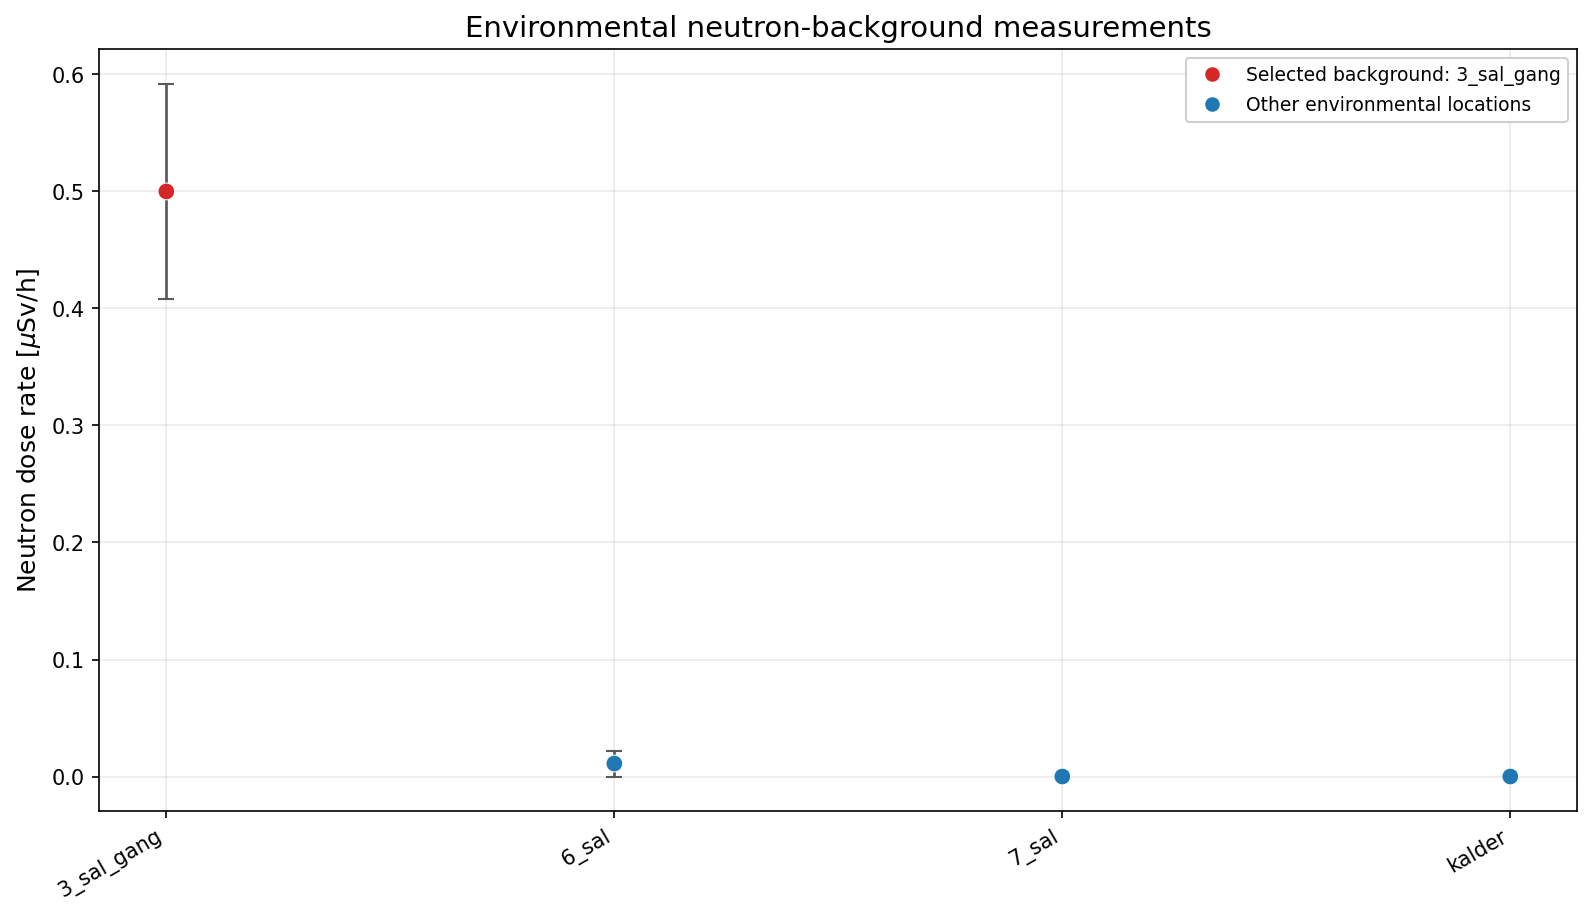

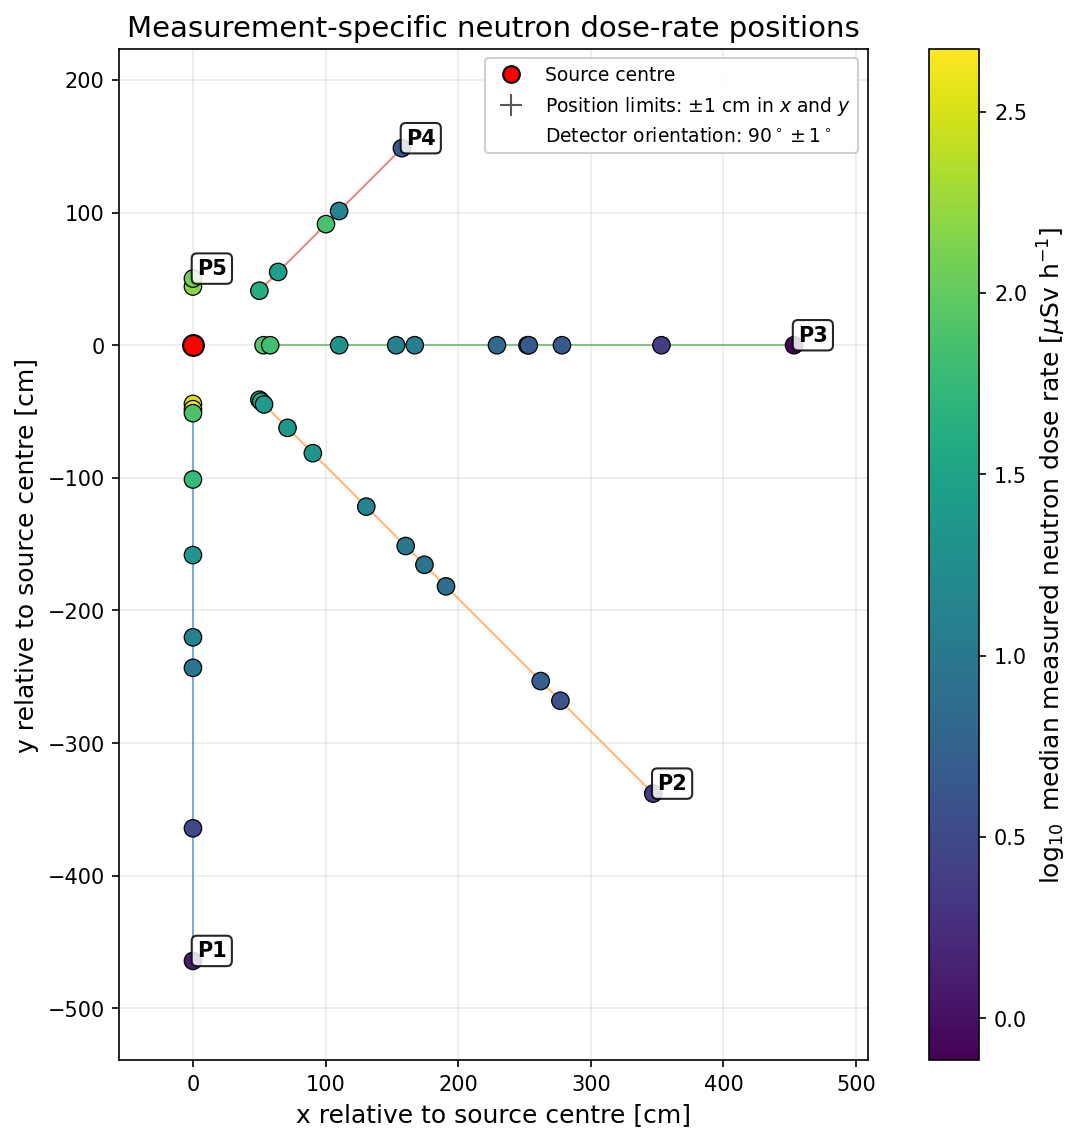

Spatial geometric limits: ±1 cm in x, y and z; detector orientation 90° ±1°.
Saved spatial plotting table: /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N4_measured_neutron_outputs/tables/12_spatial_measured_neutron_plotting_data.csv


In [7]:
# Background and spatial-geometry figures

# Re-running Section 6 should replace, rather than duplicate, its figure log.
exported_figure_rows = []


def save_figure(figure, filename_stem):
    png_path = FIGURE_DIR / f"{filename_stem}.png"
    pdf_path = FIGURE_DIR / f"{filename_stem}.pdf"
    figure.savefig(png_path, dpi=300, bbox_inches="tight")
    figure.savefig(pdf_path, bbox_inches="tight")
    for path in (png_path, pdf_path):
        exported_figure_rows.append({
            "output_type": "figure",
            "filename": path.name,
            "path": str(path.resolve()),
            "rows": np.nan,
            "status": "exported",
        })
    refresh_export_log()


def show_save_close(figure, filename_stem):
    save_figure(figure, filename_stem)
    plt.show()
    plt.close(figure)


# ------------------------------------------------------------
# Environmental background: omit the measurement at the cabinet
# ------------------------------------------------------------

background_location_text = (
    environmental_background_location_df["location_label"]
    .astype(str)
    .str.casefold()
)
cabinet_background_mask = background_location_text.str.contains(
    r"skab|cabinet",
    regex=True,
    na=False,
)
excluded_cabinet_background_df = environmental_background_location_df.loc[
    cabinet_background_mask
].copy()
background_plot_df = (
    environmental_background_location_df.loc[~cabinet_background_mask]
    .sort_values("location_label")
    .reset_index(drop=True)
)

if background_plot_df.empty:
    raise ValueError("No environmental-background locations remain for plotting.")

selected_background_present = (
    background_plot_df["location_label"].astype(str).str.casefold()
    == LOCAL_BACKGROUND_LOCATION.casefold()
).any()
if not selected_background_present:
    raise RuntimeError(
        f"The selected local background {LOCAL_BACKGROUND_LOCATION!r} was "
        "removed by the cabinet-reference filter."
    )

if not excluded_cabinet_background_df.empty:
    excluded_names = ", ".join(
        excluded_cabinet_background_df["location_label"].astype(str)
    )
    print(
        "Excluded cabinet reference measurement(s) from Section 6: "
        f"{excluded_names}."
    )
print(
    "Background subtraction uses only "
    f"{LOCAL_BACKGROUND_LOCATION!r}; cabinet-reference data are not used."
)

background_fig, background_ax = plt.subplots(
    figsize=(10.5, 6.0),
    dpi=150,
    layout="constrained",
)
background_x = np.arange(len(background_plot_df))
background_colours = [
    "tab:red"
    if str(label).casefold() == LOCAL_BACKGROUND_LOCATION.casefold()
    else "tab:blue"
    for label in background_plot_df["location_label"]
]
background_ax.errorbar(
    background_x,
    background_plot_df["pooled_mean_uSv_h"],
    yerr=background_plot_df["pooled_sem_uSv_h"],
    fmt="none",
    ecolor="0.35",
    elinewidth=1.3,
    capsize=4,
    zorder=2,
)
background_ax.scatter(
    background_x,
    background_plot_df["pooled_mean_uSv_h"],
    c=background_colours,
    s=65,
    edgecolor="white",
    linewidth=0.5,
    zorder=3,
)
background_ax.set_xticks(
    background_x,
    background_plot_df["location_label"],
    rotation=30,
    ha="right",
)
background_ax.set_ylabel(r"Neutron dose rate [$\mu$Sv/h]")
background_ax.set_title("Environmental neutron-background measurements")
background_ax.grid(True, axis="y", alpha=0.25)
background_ax.legend(
    handles=[
        Line2D(
            [0], [0], marker="o", color="none", markerfacecolor="tab:red",
            markeredgecolor="white", markersize=8,
            label=f"Selected background: {LOCAL_BACKGROUND_LOCATION}",
        ),
        Line2D(
            [0], [0], marker="o", color="none", markerfacecolor="tab:blue",
            markeredgecolor="white", markersize=8,
            label="Other environmental locations",
        ),
    ],
    loc="best",
    framealpha=0.92,
)
show_save_close(background_fig, "environmental_neutron_background")


# ------------------------------------------------------------
# Spatial XY map in the same style as the simulated scan map
# ------------------------------------------------------------

positive_geometry_df = geometry_plot_df.loc[
    geometry_plot_df["net_mean_uSv_h"] > 0.0
].copy()
omitted_geometry_points = len(geometry_plot_df) - len(positive_geometry_df)
if positive_geometry_df.empty:
    raise ValueError("The spatial neutron-field plot has no positive dose rates.")
if omitted_geometry_points:
    print(
        f"Spatial plot omitted {omitted_geometry_points} non-positive "
        "dose-rate point(s) because logarithmic colour scaling is used."
    )

# Several heights share each plan-view coordinate. The median over the actual
# heights gives one unambiguous colour per XY point, matching the simulation map.
spatial_measured_df = (
    positive_geometry_df
    .groupby(
        [
            "position",
            "distance_cm",
            "geometry_x_cm",
            "geometry_y_cm",
            "direction_x",
            "direction_y",
        ],
        as_index=False,
    )
    .agg(
        median_neutron_dose_rate_uSv_h=("net_mean_uSv_h", "median"),
        median_combined_sem_uSv_h=("net_sem_effective_uSv_h", "median"),
        number_of_heights=("height_cm", "nunique"),
    )
)

# Treat ±1 cm in x, y and z and 90°±1° orientation as separate symmetric
# geometric setup limits. An angular-response correction is not inferred from
# the orientation limit, and it is not added to the vertical dose-rate SEM.
spatial_measured_df["x_position_limit_cm"] = (
    MEASUREMENT_POSITION_UNCERTAINTY_CM
)
spatial_measured_df["y_position_limit_cm"] = (
    MEASUREMENT_POSITION_UNCERTAINTY_CM
)
spatial_measured_df["z_position_limit_cm"] = (
    MEASUREMENT_POSITION_UNCERTAINTY_CM
)
spatial_measured_df["position_limit_cm_each_axis"] = (
    MEASUREMENT_POSITION_UNCERTAINTY_CM
)
spatial_measured_df["instrument_orientation_deg"] = (
    STUDSVIK_MEASUREMENT_ORIENTATION_DEG
)
spatial_measured_df["instrument_orientation_limit_deg"] = (
    STUDSVIK_ORIENTATION_UNCERTAINTY_DEG
)

spatial_uncertainty_table_path = (
    TABLE_DIR / "12_spatial_measured_neutron_plotting_data.csv"
)
spatial_measured_df.to_csv(spatial_uncertainty_table_path, index=False)

geometry_fig, geometry_ax = plt.subplots(
    figsize=(8.5, 7.5),
    dpi=150,
    layout="constrained",
)

# Draw P1--P5 direction lines and geometric limits behind the coloured points.
for position, position_data in spatial_measured_df.groupby("position", sort=True):
    xy_data = position_data.sort_values("distance_cm")
    geometry_ax.plot(
        xy_data["geometry_x_cm"],
        xy_data["geometry_y_cm"],
        color=POSITION_COLORS[position],
        linewidth=1.0,
        alpha=0.55,
        zorder=2,
    )
    geometry_ax.errorbar(
        xy_data["geometry_x_cm"],
        xy_data["geometry_y_cm"],
        xerr=xy_data["x_position_limit_cm"],
        yerr=xy_data["y_position_limit_cm"],
        fmt="none",
        ecolor="0.35",
        elinewidth=1.0,
        capsize=3.0,
        alpha=0.65,
        zorder=3,
    )

    label_row = xy_data.iloc[-1]
    geometry_ax.text(
        label_row["geometry_x_cm"] + 3.0,
        label_row["geometry_y_cm"] + 3.0,
        position,
        fontsize=10,
        fontweight="bold",
        bbox={
            "boxstyle": "round,pad=0.25",
            "facecolor": "white",
            "edgecolor": "black",
            "alpha": 0.85,
        },
        zorder=6,
    )

geometry_scatter = geometry_ax.scatter(
    spatial_measured_df["geometry_x_cm"],
    spatial_measured_df["geometry_y_cm"],
    c=np.log10(spatial_measured_df["median_neutron_dose_rate_uSv_h"]),
    s=70,
    edgecolor="black",
    linewidth=0.6,
    zorder=4,
)
geometry_ax.scatter(
    [0.0],
    [0.0],
    s=100,
    color="red",
    edgecolor="black",
    label="Source centre",
    zorder=5,
)

geometry_colorbar = geometry_fig.colorbar(geometry_scatter, ax=geometry_ax)
geometry_colorbar.set_label(
    r"$\log_{10}$ median measured neutron dose rate "
    r"[$\mu$Sv h$^{-1}$]"
)
geometry_ax.set_xlabel("x relative to source centre [cm]")
geometry_ax.set_ylabel("y relative to source centre [cm]")
geometry_ax.set_title("Measurement-specific neutron dose-rate positions")
geometry_ax.set_aspect("equal", adjustable="box")
geometry_ax.grid(alpha=0.25)
geometry_ax.margins(0.12)
geometry_ax.legend(
    handles=[
        Line2D(
            [0], [0], marker="o", color="none", markerfacecolor="red",
            markeredgecolor="black", markersize=8, label="Source centre",
        ),
        Line2D(
            [0], [0], marker="+", color="0.35", linestyle="none",
            markersize=11,
            label=(
                r"Position limits: $\pm1$ cm in $x$ and $y$"
            ),
        ),
        Line2D(
            [0], [0], color="none", linestyle="none",
            label=r"Detector orientation: $90^\circ\pm1^\circ$",
        ),
    ],
    loc="best",
    framealpha=0.92,
)
show_save_close(geometry_fig, "measured_neutron_geometry_xy")

print(
    "Spatial geometric limits: "
    f"±{MEASUREMENT_POSITION_UNCERTAINTY_CM:g} cm in x, y and z; "
    f"detector orientation {STUDSVIK_MEASUREMENT_ORIENTATION_DEG:g}° "
    f"±{STUDSVIK_ORIENTATION_UNCERTAINTY_DEG:g}°."
)
print(f"Saved spatial plotting table: {spatial_uncertainty_table_path}")


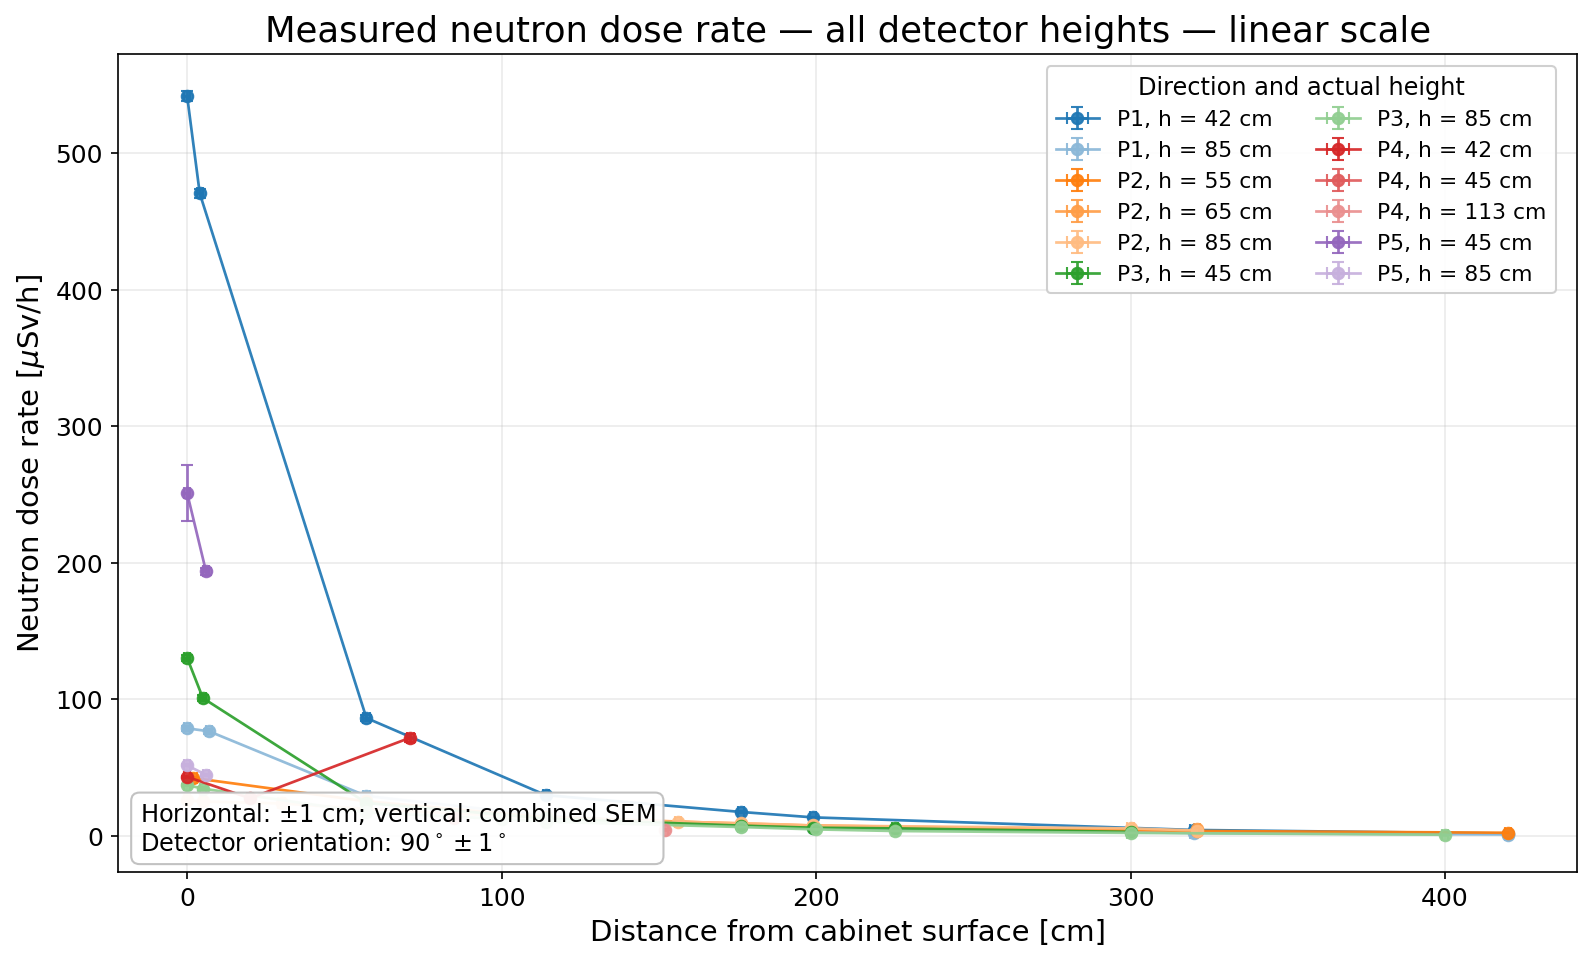

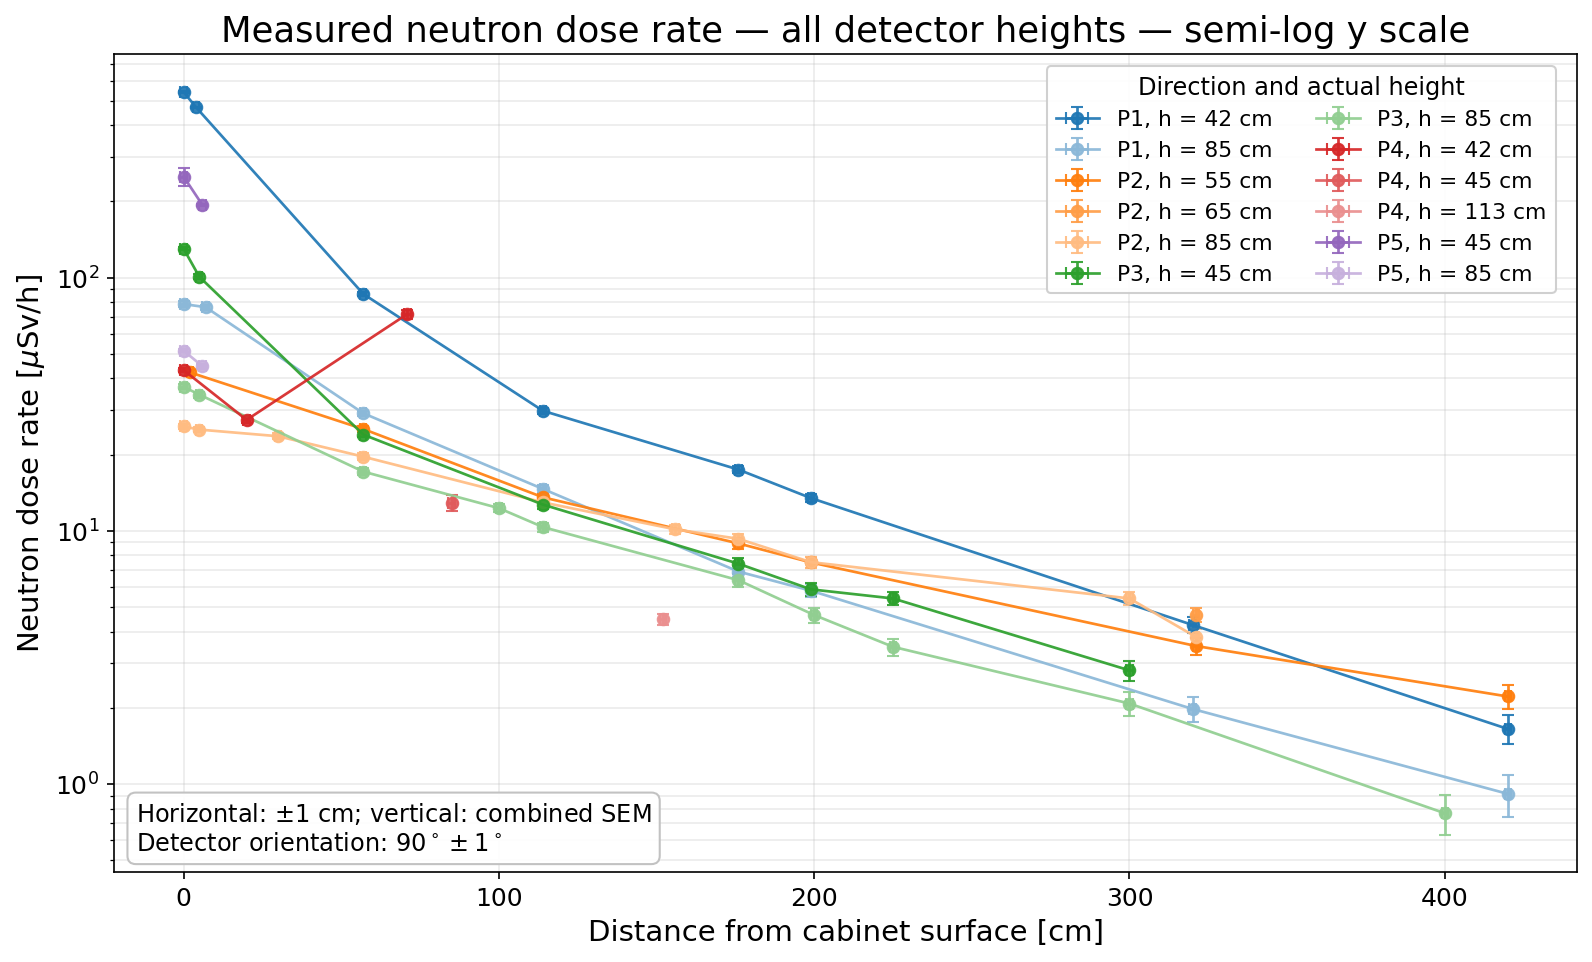

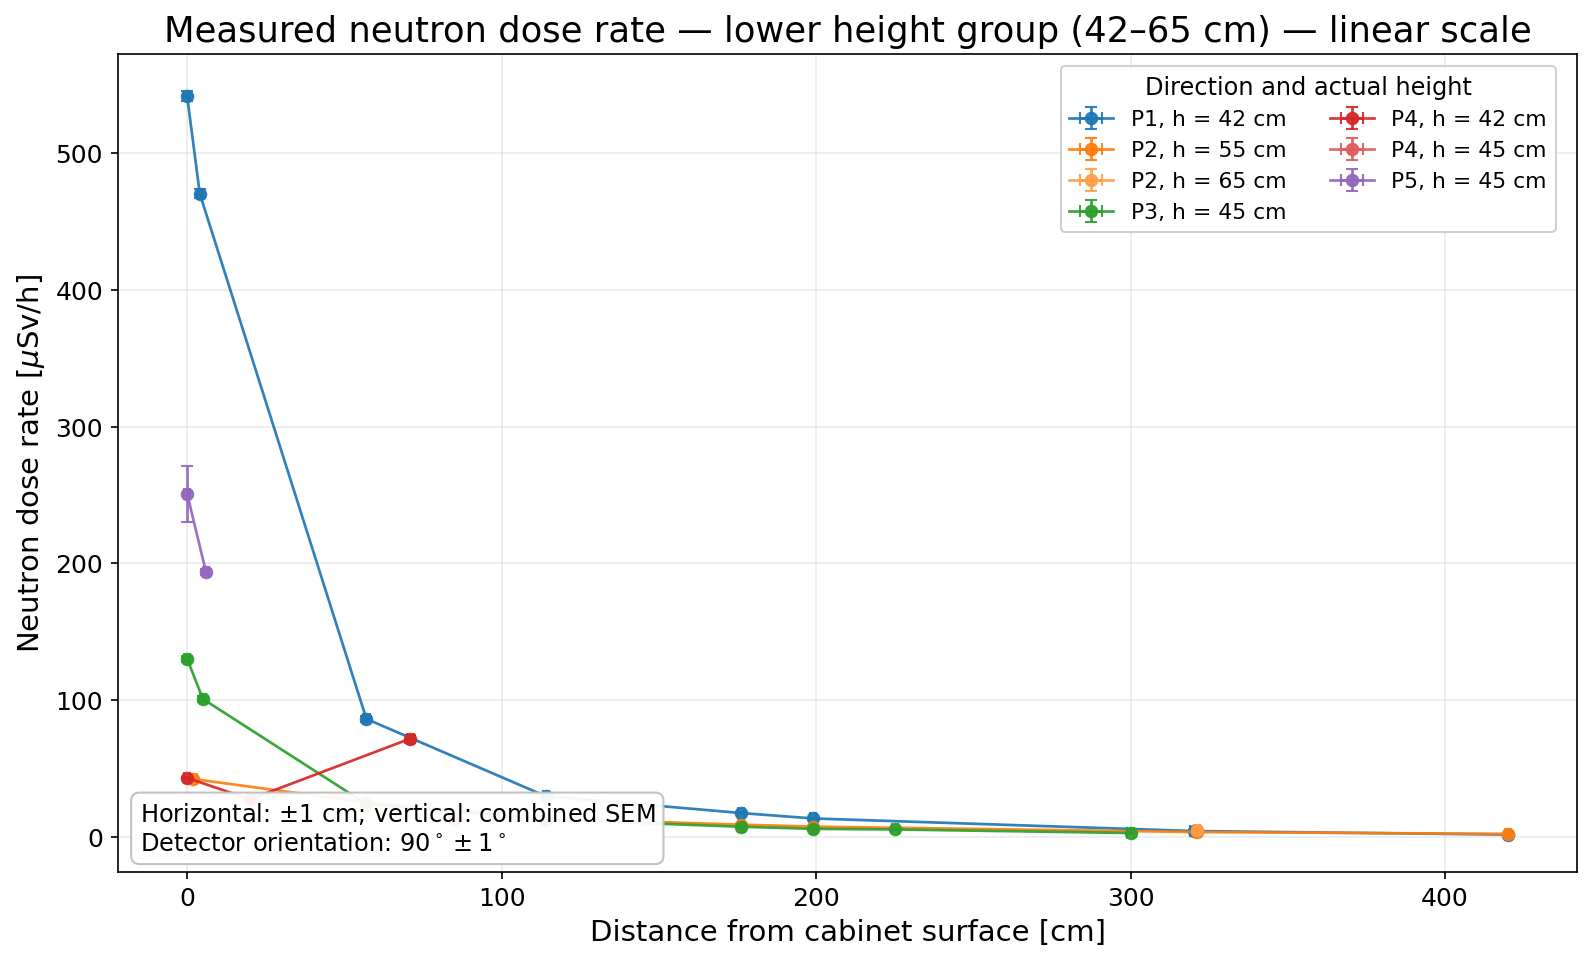

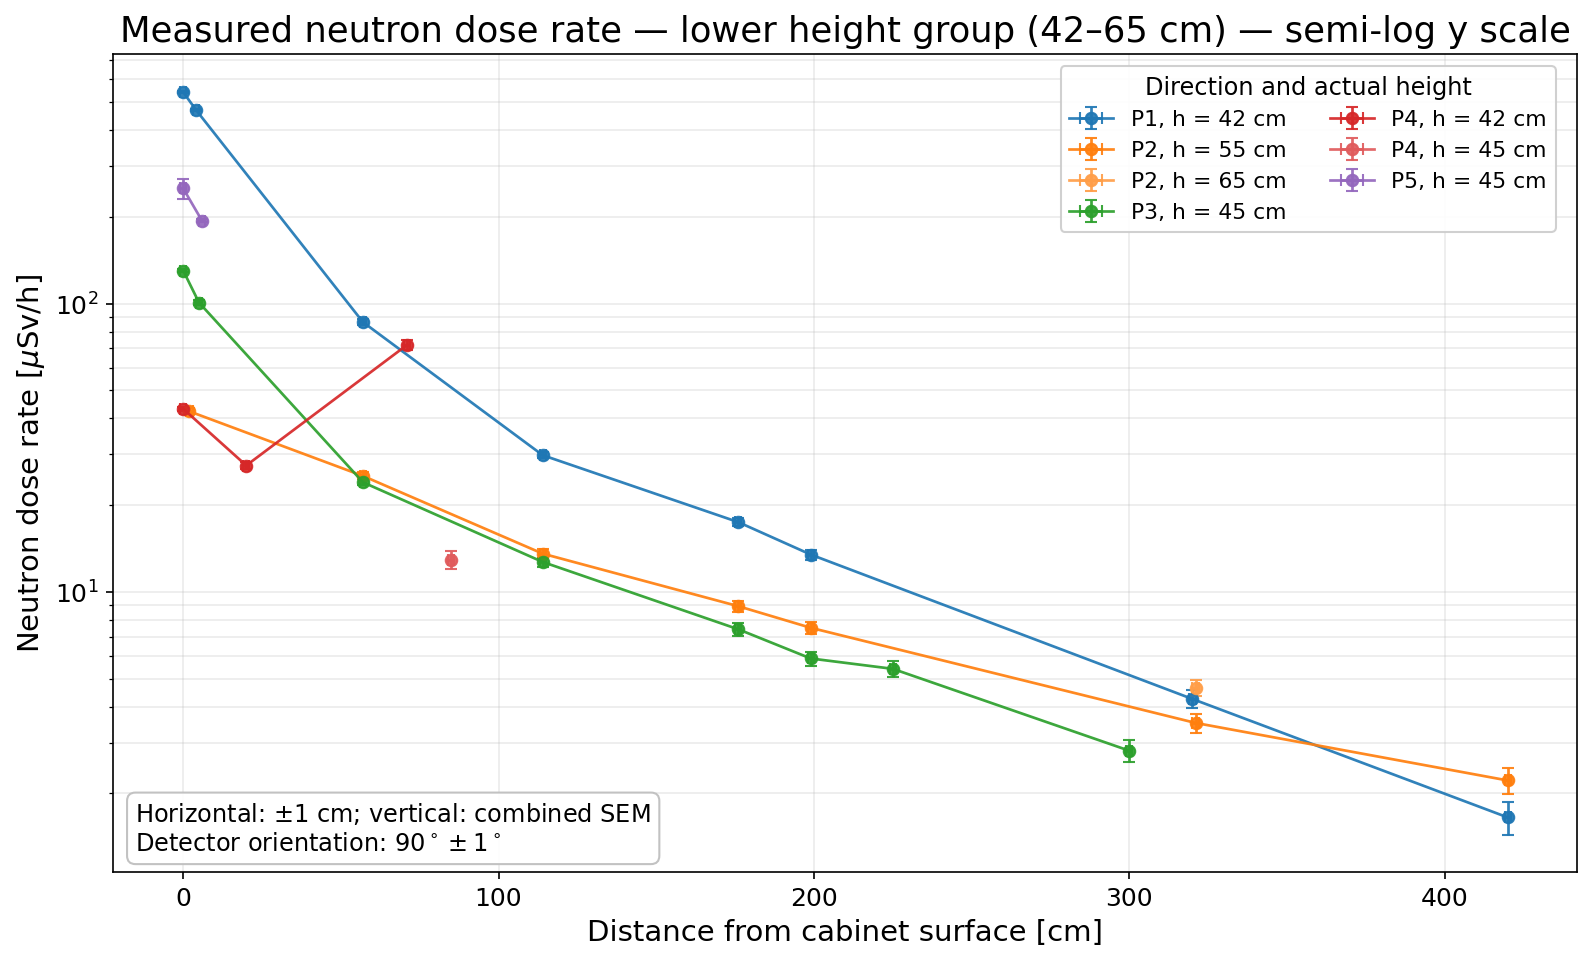

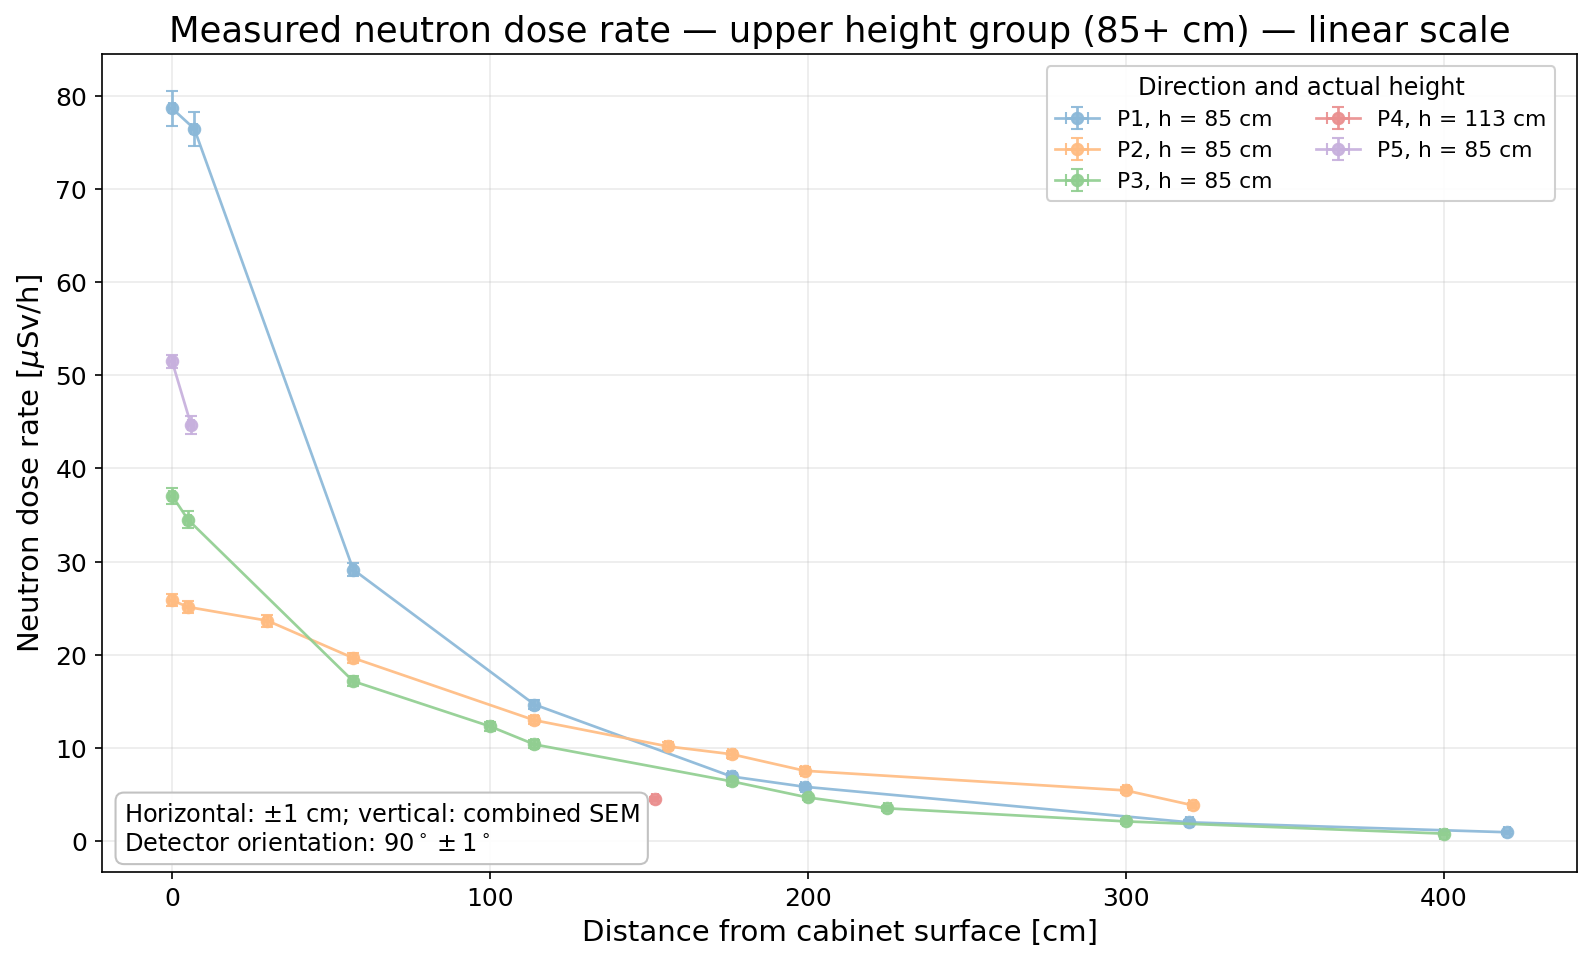

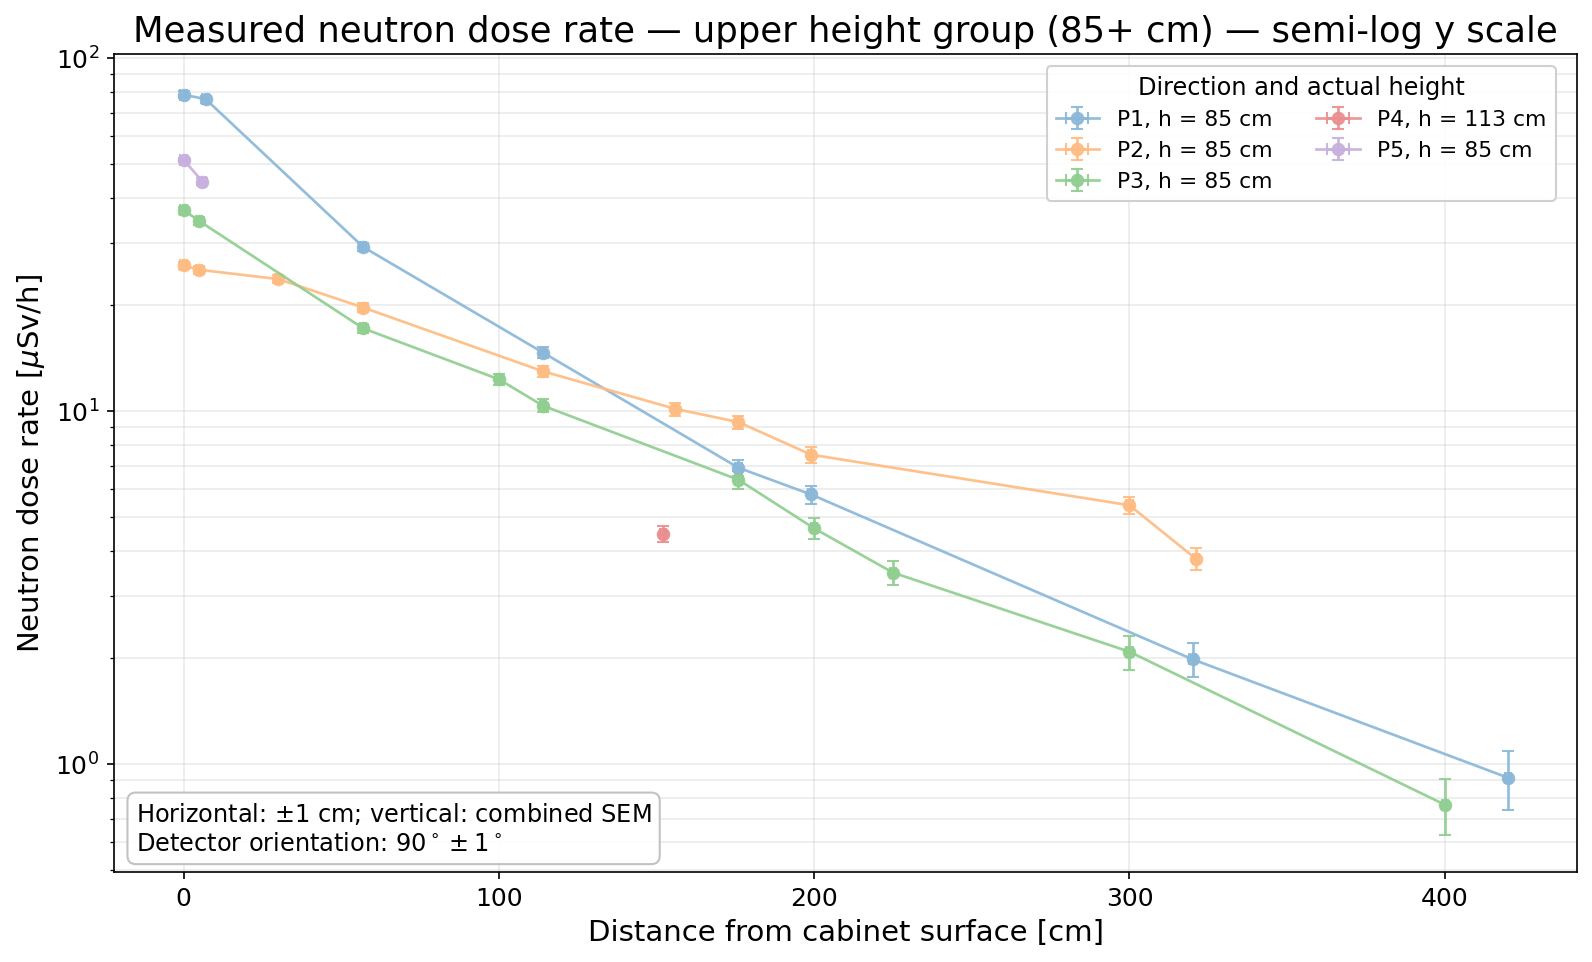

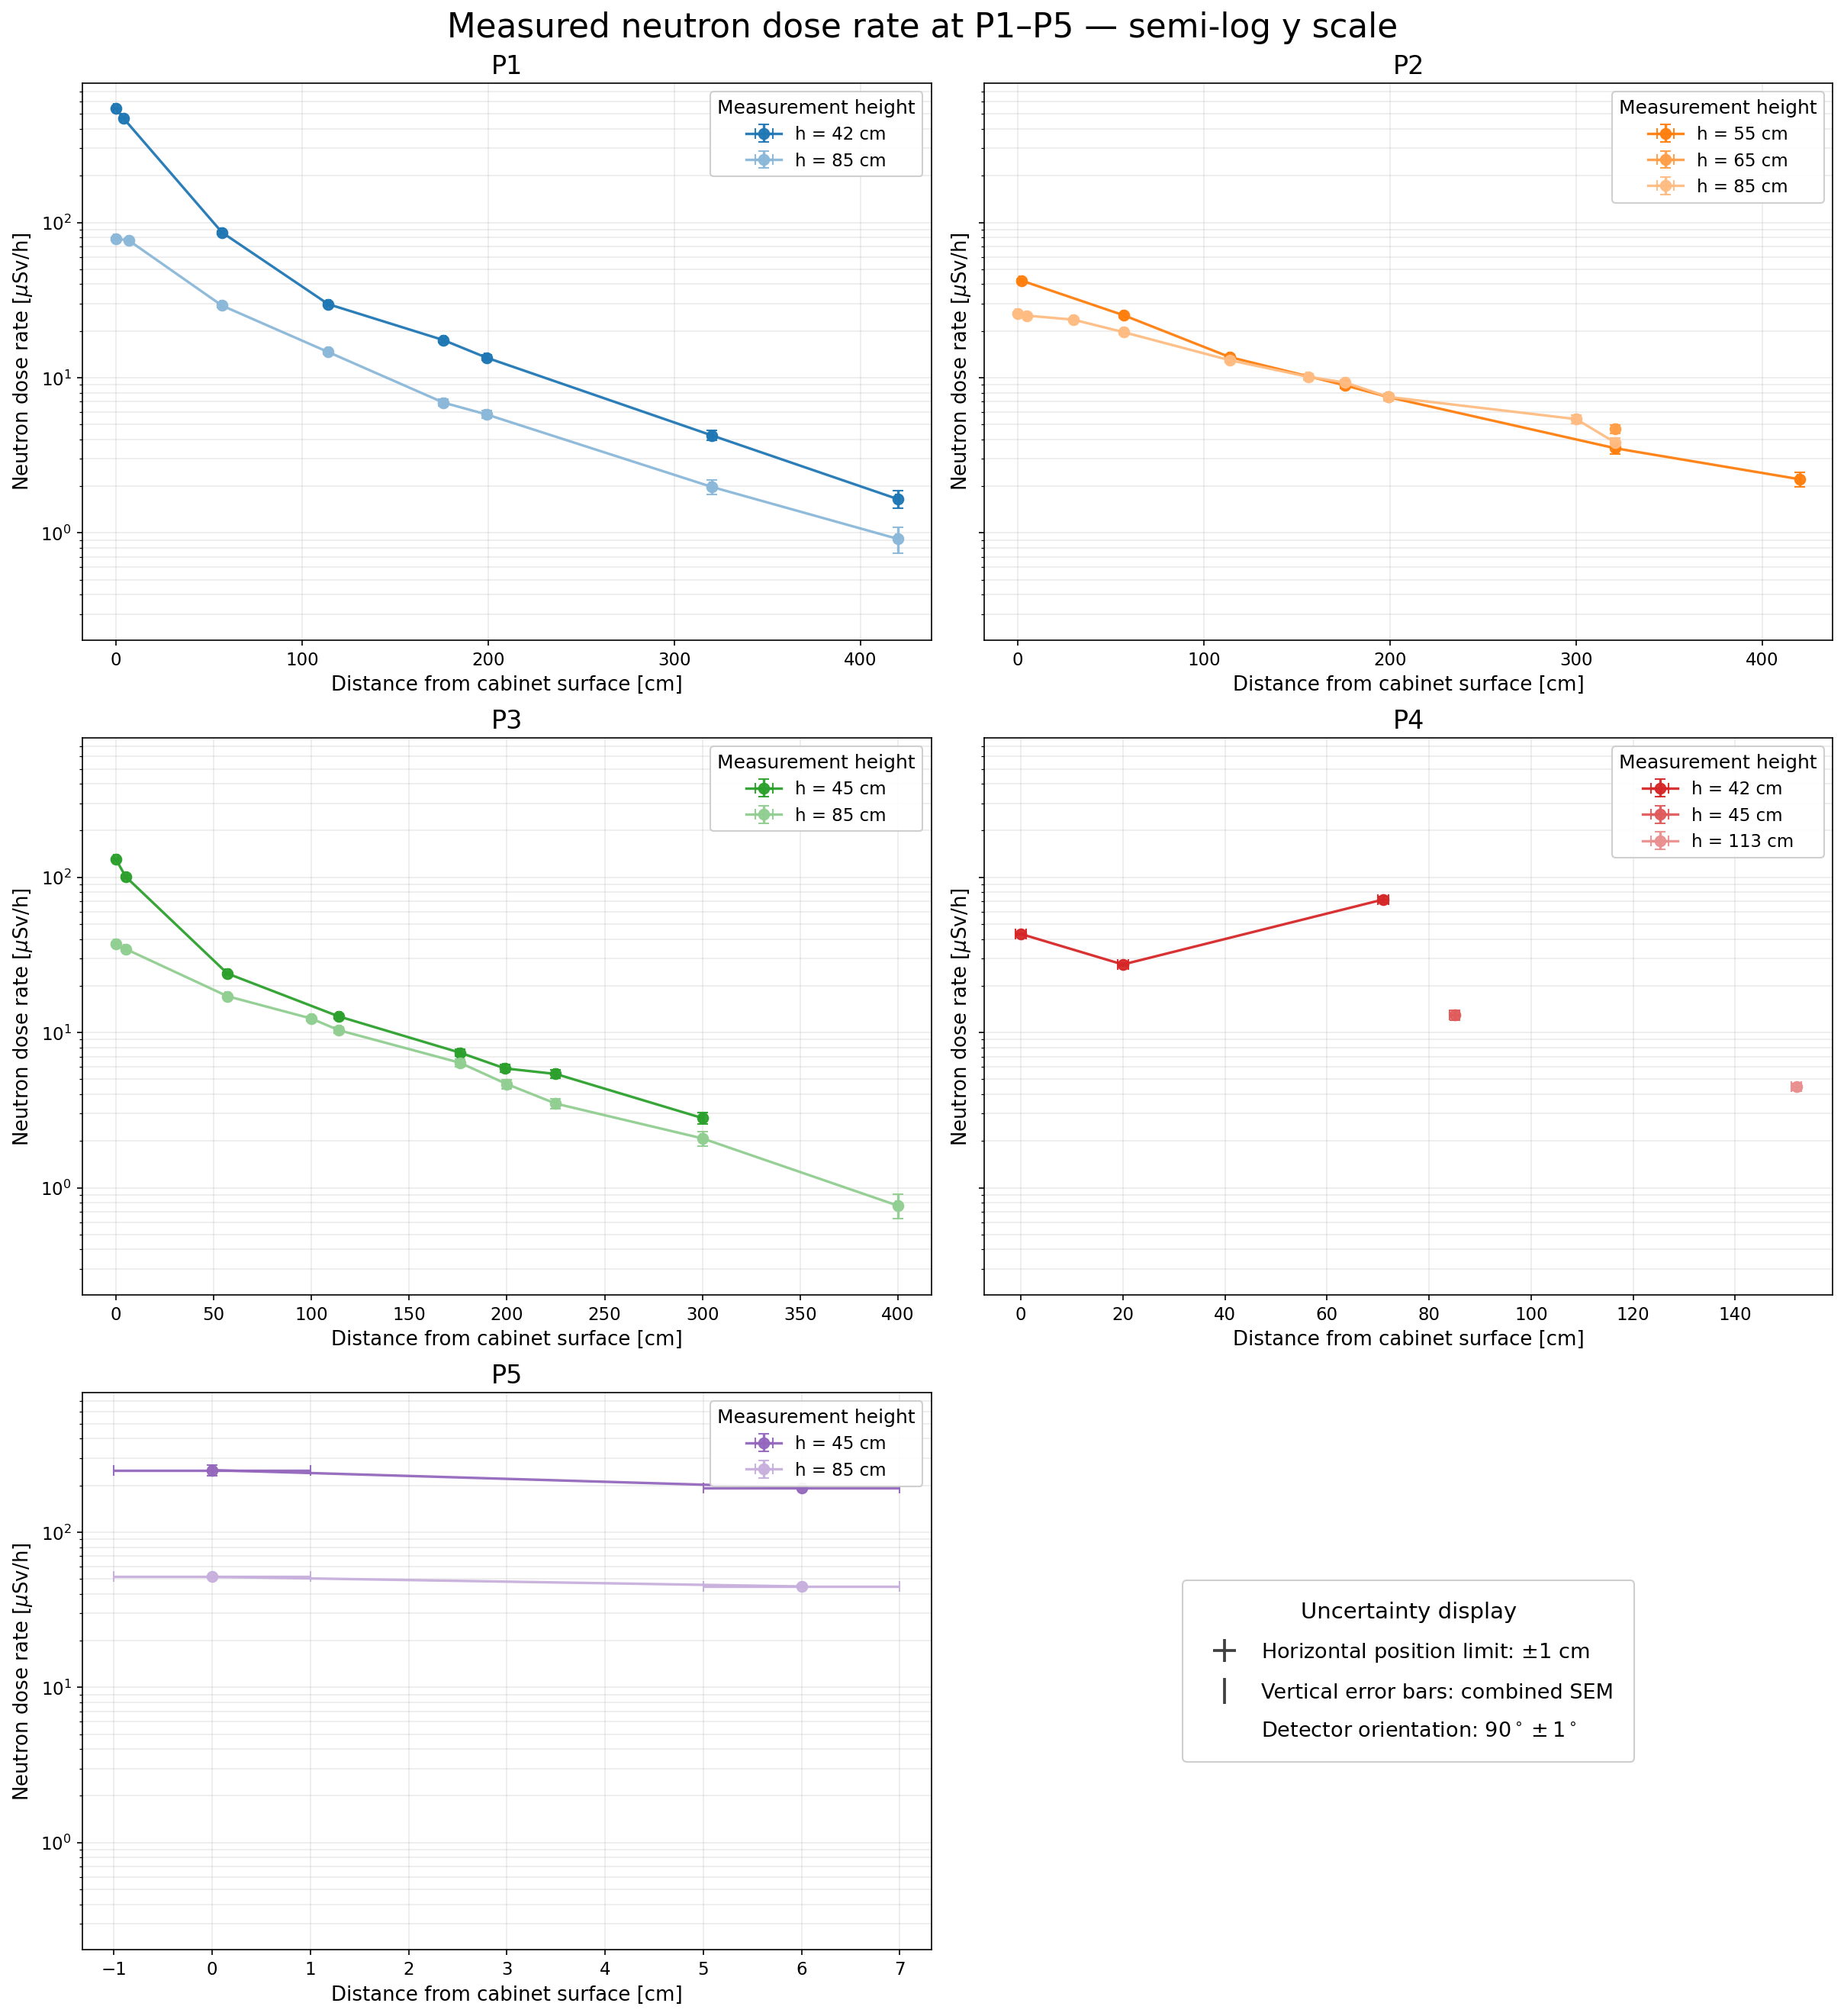

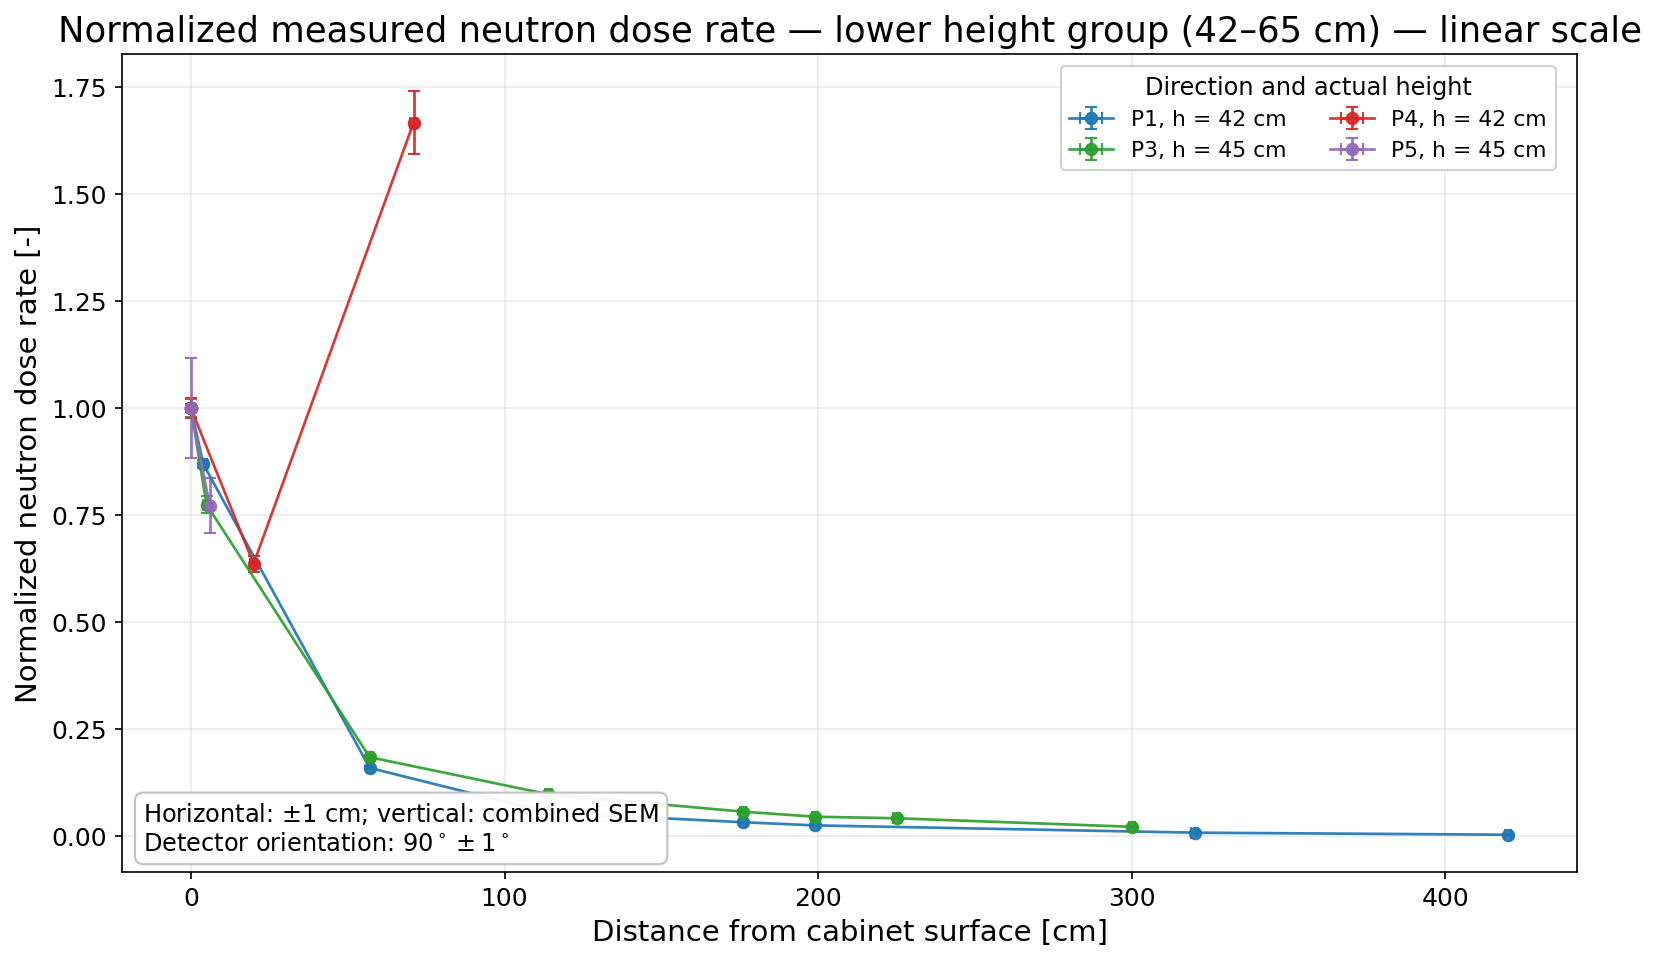

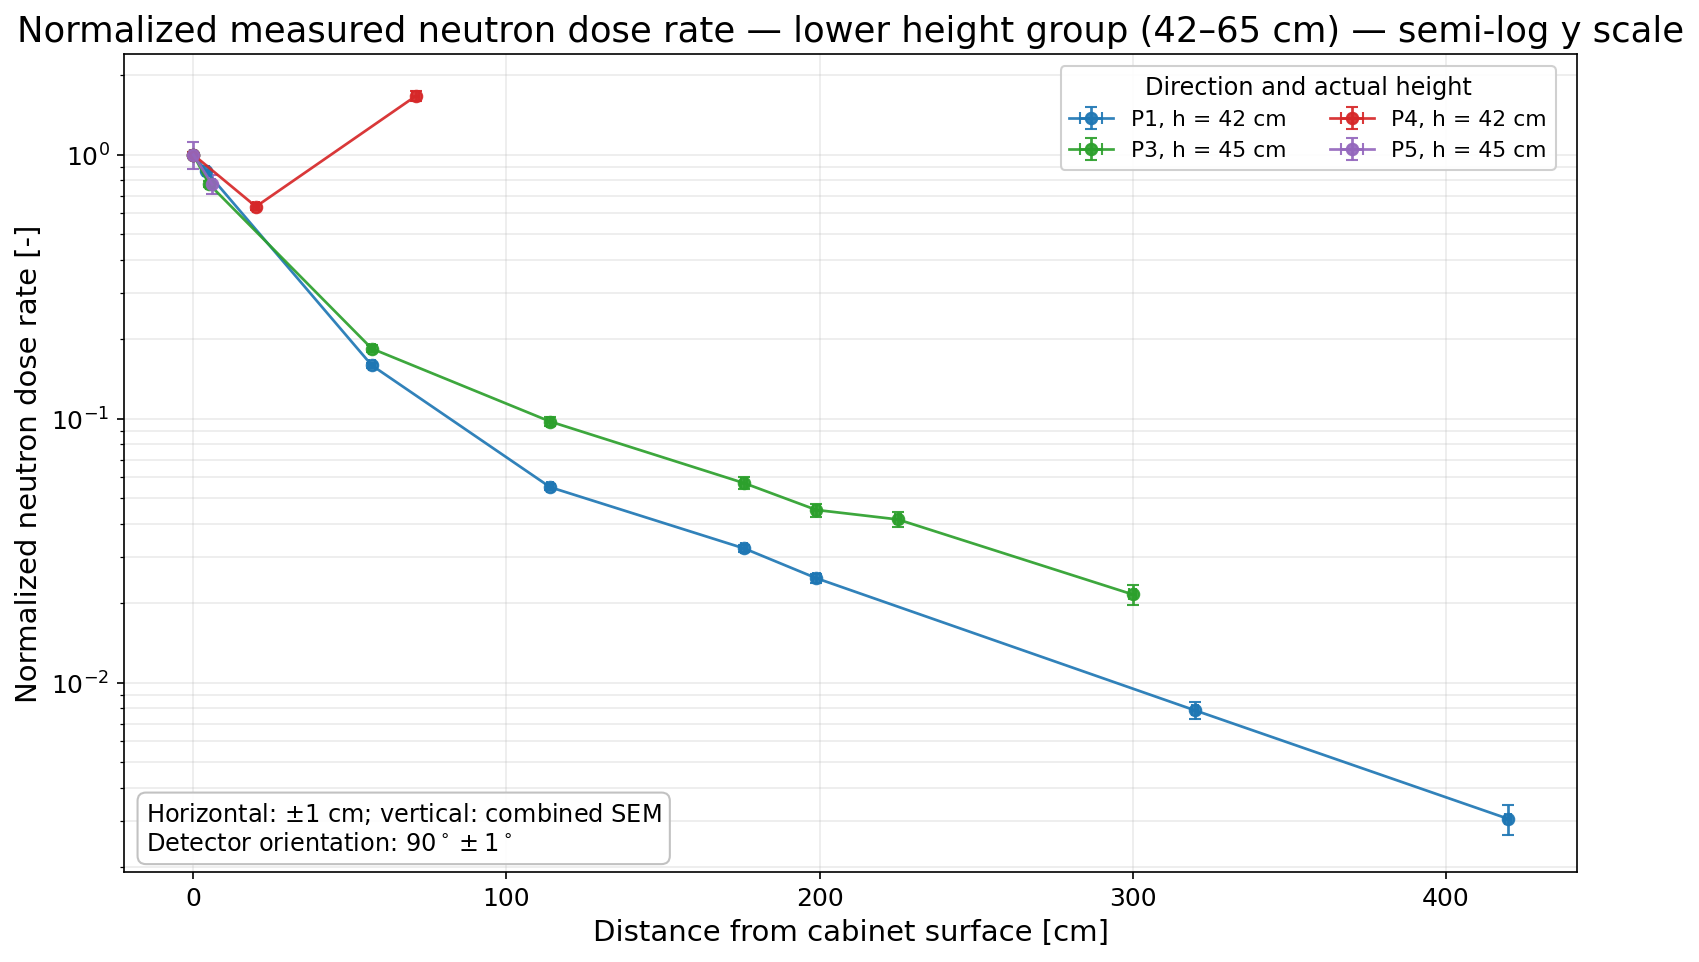

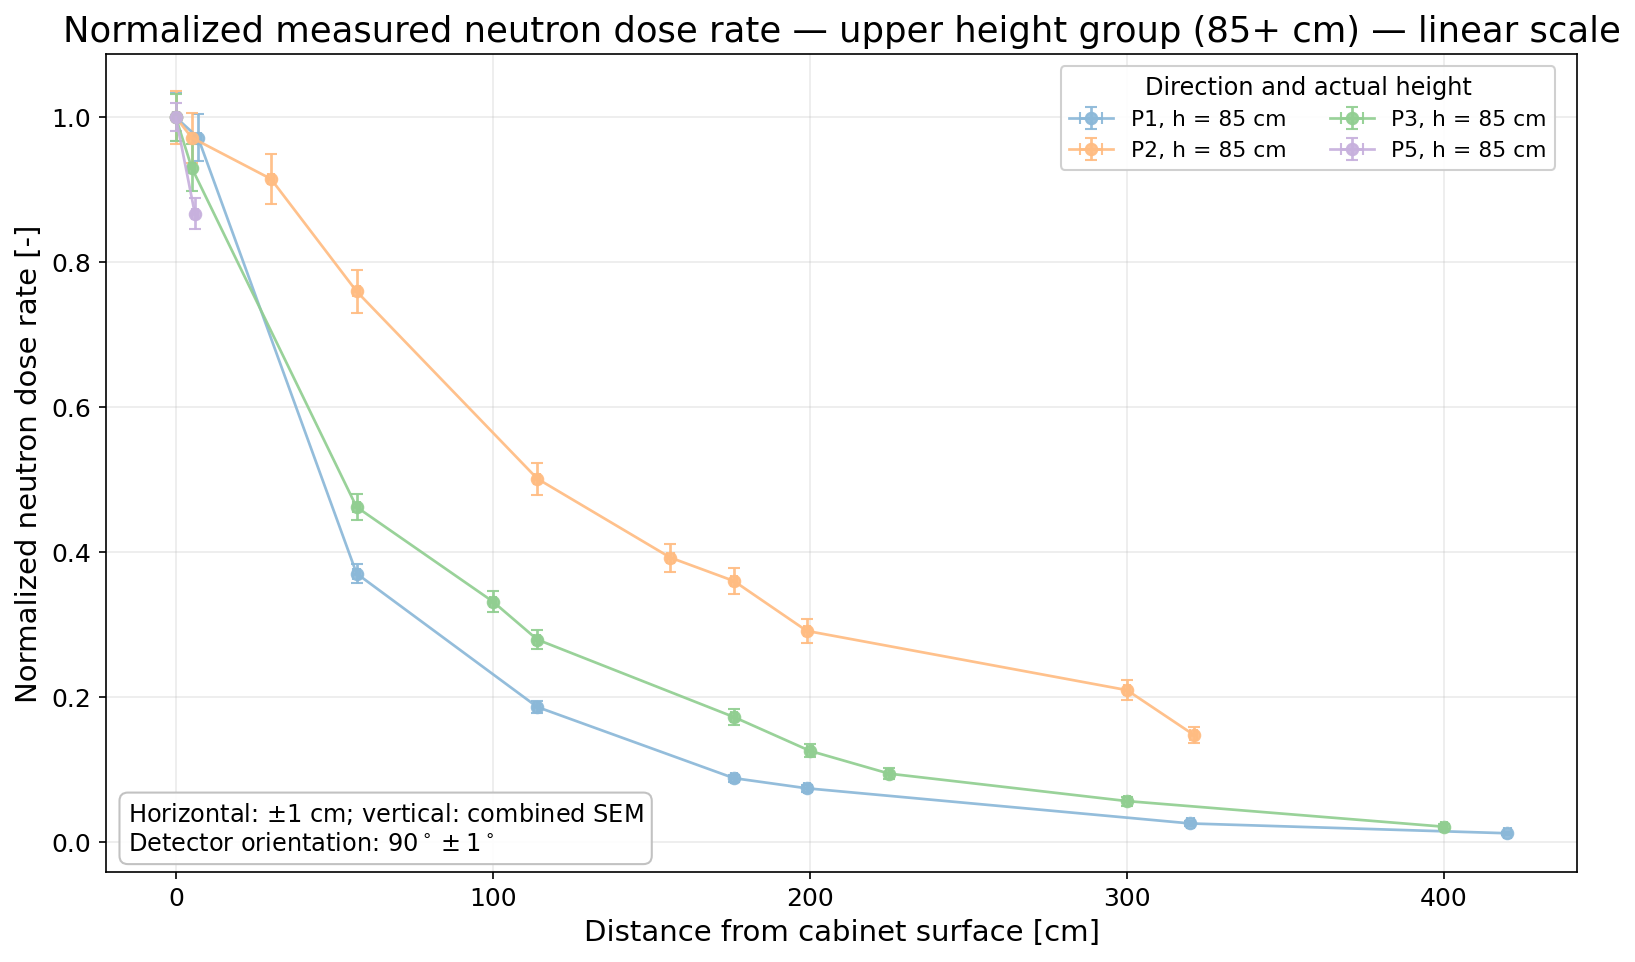

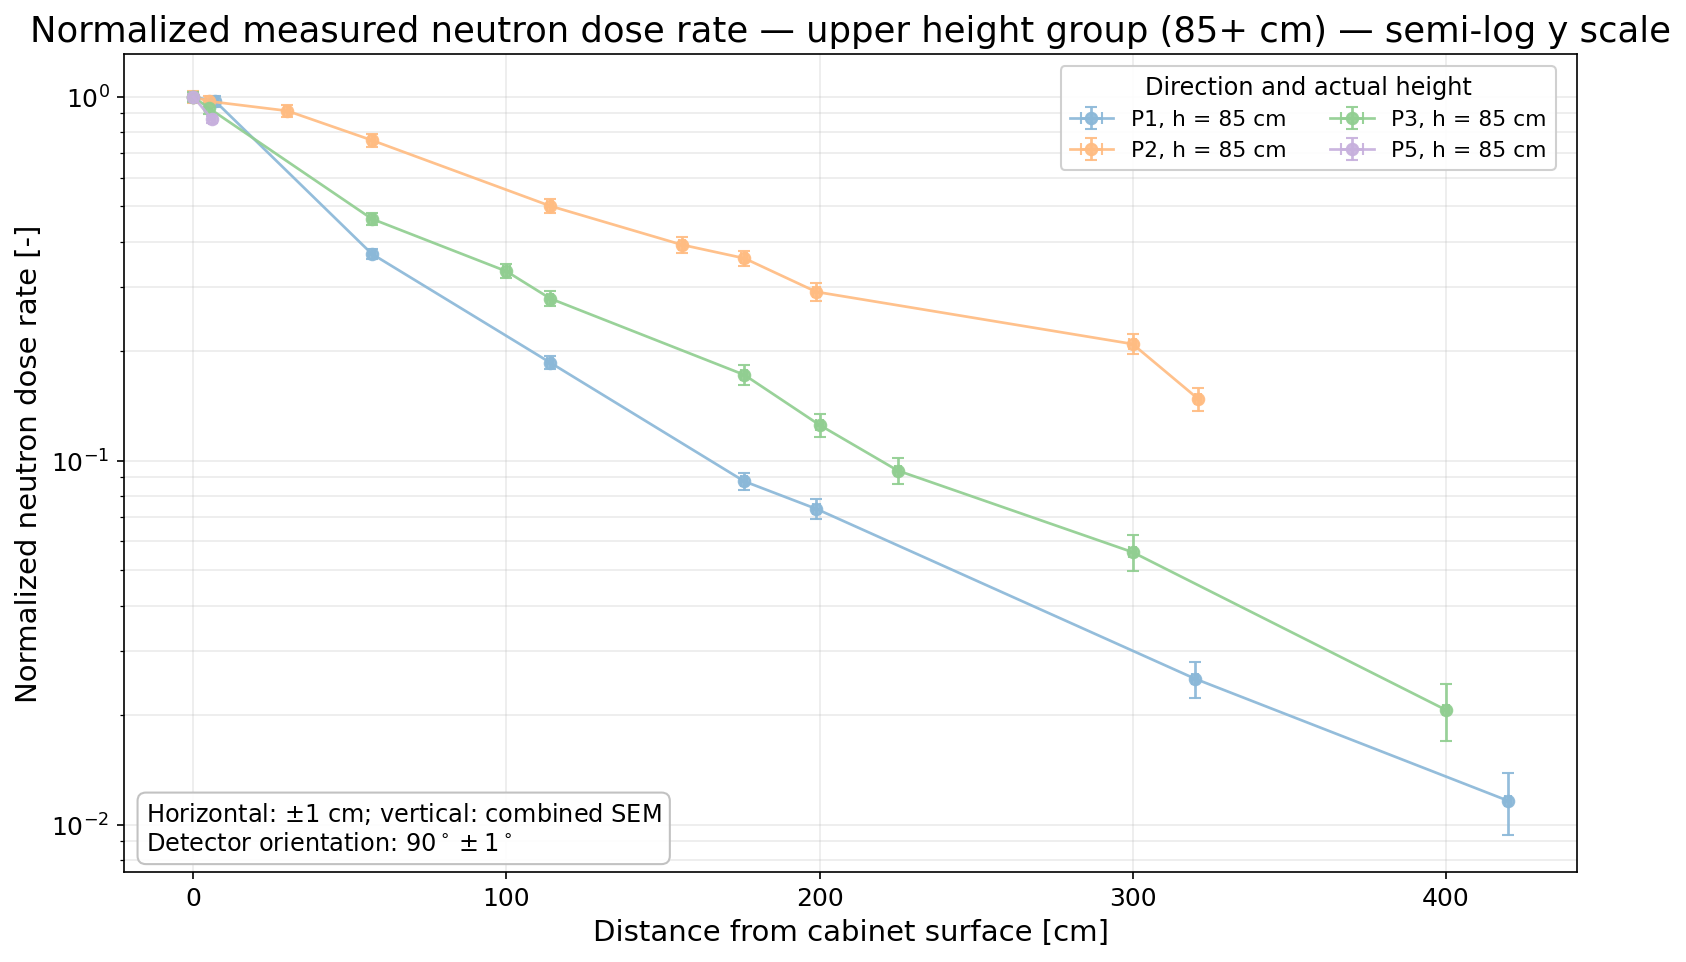

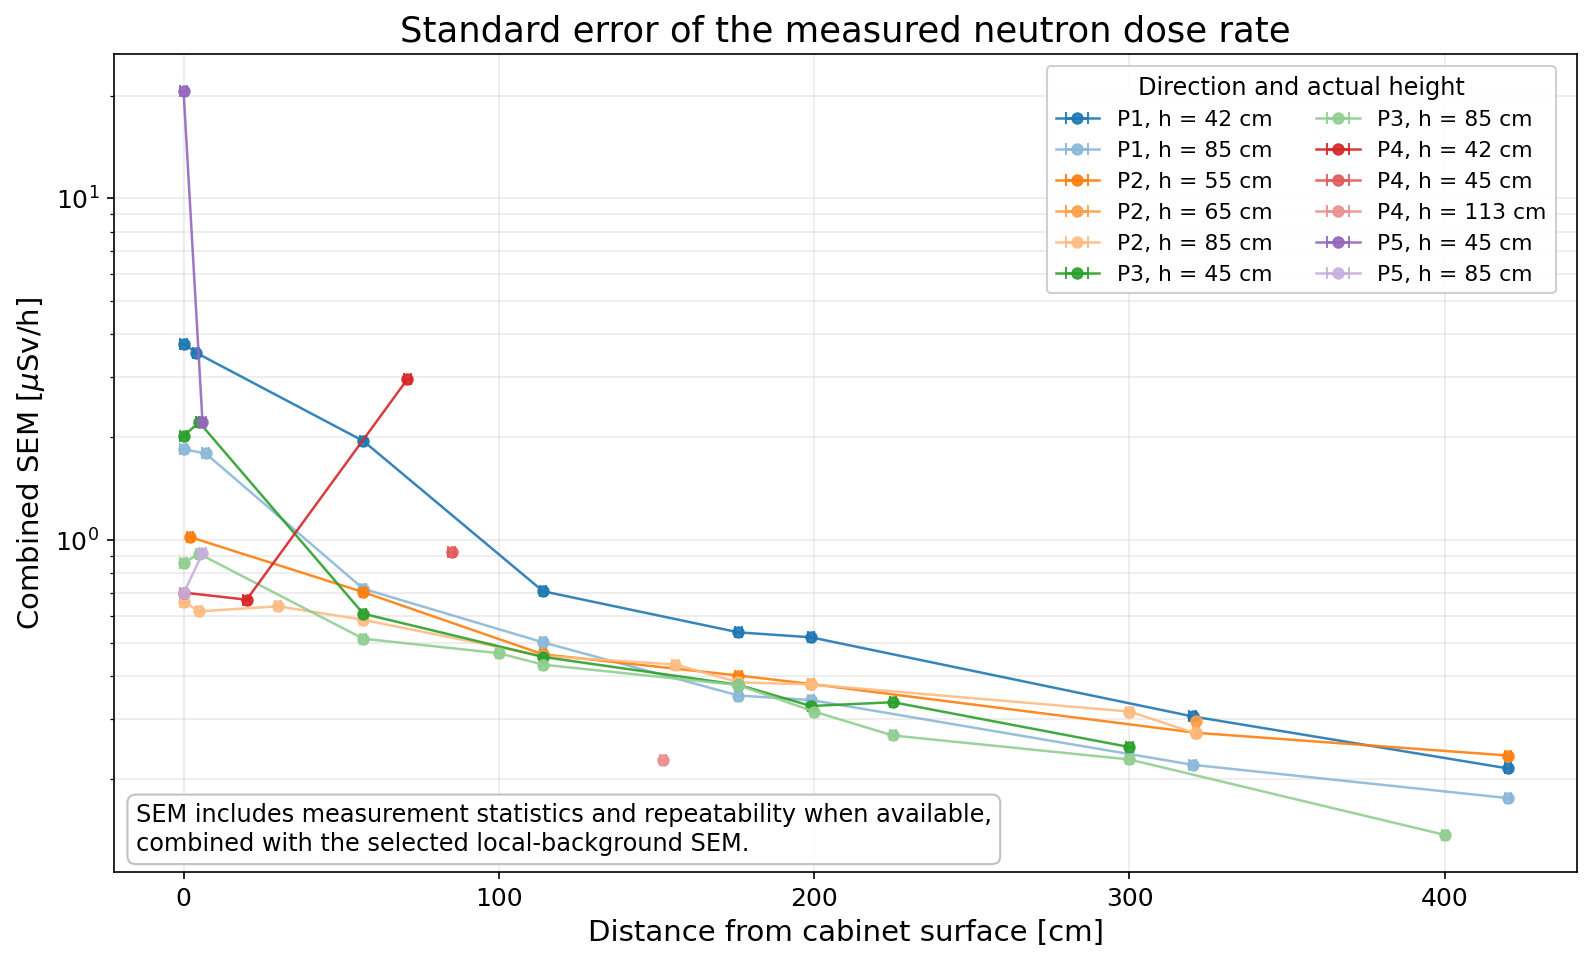

Saved figure files: 50
Figure folder: /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N4_measured_neutron_outputs/figures


In [10]:
# Dose-rate, attenuation, semi-log and SEM figures

def log_safe_yerr(mean, uncertainty):
    mean = np.asarray(mean, dtype=float)
    uncertainty = np.asarray(uncertainty, dtype=float)
    lower = np.minimum(
        uncertainty,
        np.maximum(mean * (1.0 - 1.0e-6), 0.0),
    )
    return np.vstack([lower, uncertainty])


FIGURE_TITLE_FONTSIZE = 17
FIGURE_SUPTITLE_FONTSIZE = 21
FIGURE_LABEL_FONTSIZE = 14
FIGURE_TICK_FONTSIZE = 12
FIGURE_LEGEND_FONTSIZE = 10.5
FIGURE_LEGEND_TITLE_FONTSIZE = 11.5
FIGURE_NOTE_FONTSIZE = 11.5


def style_axis_text(
    axis,
    title_size=FIGURE_TITLE_FONTSIZE,
    label_size=FIGURE_LABEL_FONTSIZE,
    tick_size=FIGURE_TICK_FONTSIZE,
):
    axis.title.set_fontsize(title_size)
    axis.xaxis.label.set_size(label_size)
    axis.yaxis.label.set_size(label_size)
    axis.tick_params(axis="both", which="both", labelsize=tick_size)


def uncertainty_note(axis, include_angle=False):
    text = r"Horizontal: $\pm1$ cm; vertical: combined SEM"
    if include_angle:
        text += "\n" + r"Detector orientation: $90^\circ\pm1^\circ$"

    axis.text(
        0.015,
        0.02,
        text,
        transform=axis.transAxes,
        fontsize=FIGURE_NOTE_FONTSIZE,
        va="bottom",
        ha="left",
        linespacing=1.25,
        zorder=20,
        bbox={
            "boxstyle": "round,pad=0.35",
            "facecolor": "white",
            "edgecolor": "0.75",
            "alpha": 0.94,
        },
    )


POSITION_HEIGHT_COLOURS = make_position_height_colors(
    measured_dose_rate_plot_df
)


def plot_dose_rate(
    dataframe,
    title,
    filename_stem,
    y_scale="linear",
    legend_ncol=2,
):
    if y_scale not in {"linear", "log"}:
        raise ValueError("y_scale must be 'linear' or 'log'.")

    figure, axis = plt.subplots(
        figsize=(10.5, 6.3),
        dpi=150,
        layout="constrained",
    )

    for (position, height_cm), group in dataframe.groupby(
        ["position", "height_cm"],
        sort=True,
    ):
        group = group.sort_values("distance_cm")

        if y_scale == "log":
            group = group.loc[group["net_mean_uSv_h"] > 0.0]

        if group.empty:
            continue

        vertical_uncertainty = group["net_sem_effective_uSv_h"]

        if y_scale == "log":
            vertical_uncertainty = log_safe_yerr(
                group["net_mean_uSv_h"],
                vertical_uncertainty,
            )

        axis.errorbar(
            group["distance_cm"],
            group["net_mean_uSv_h"],
            xerr=np.full(
                len(group),
                MEASUREMENT_POSITION_UNCERTAINTY_CM,
            ),
            yerr=vertical_uncertainty,
            fmt="o-",
            linewidth=1.3,
            markersize=5.5,
            capsize=3,
            color=POSITION_HEIGHT_COLOURS[
                (position, float(height_cm))
            ],
            alpha=0.92,
            label=f"{position}, h = {height_cm:g} cm",
        )

    if y_scale == "log":
        axis.set_yscale("log")

    axis.set_xlabel("Distance from cabinet surface [cm]")
    axis.set_ylabel(r"Neutron dose rate [$\mu$Sv/h]")

    scale_text = (
        "semi-log y scale"
        if y_scale == "log"
        else "linear scale"
    )
    axis.set_title(f"{title} — {scale_text}")
    axis.grid(True, which="both", alpha=0.25)

    style_axis_text(axis)

    axis.legend(
        title="Direction and actual height",
        loc="upper right",
        bbox_to_anchor=(0.985, 0.985),
        borderaxespad=0.0,
        ncol=legend_ncol,
        fontsize=FIGURE_LEGEND_FONTSIZE,
        title_fontsize=FIGURE_LEGEND_TITLE_FONTSIZE,
        frameon=True,
        framealpha=0.92,
        facecolor="white",
    )

    uncertainty_note(axis, include_angle=True)
    show_save_close(figure, filename_stem)

    return figure, axis


dose_plot_specs = [
    (
        measured_dose_rate_plot_df,
        "Measured neutron dose rate — all detector heights",
        "measured_neutron_dose_rate_all_points",
    ),
    (
        lower_height_dose_rate_df,
        "Measured neutron dose rate — lower height group (42–65 cm)",
        "measured_neutron_dose_rate_lower_height",
    ),
    (
        upper_height_dose_rate_df,
        "Measured neutron dose rate — upper height group (85+ cm)",
        "measured_neutron_dose_rate_upper_height",
    ),
]


for dose_dataframe, dose_title, dose_stem in dose_plot_specs:
    plot_dose_rate(
        dose_dataframe,
        dose_title,
        f"{dose_stem}_linear",
        y_scale="linear",
    )

    # The established filename is retained for the semi-log version.
    plot_dose_rate(
        dose_dataframe,
        dose_title,
        dose_stem,
        y_scale="log",
    )


# ------------------------------------------------------------
# One semi-log panel for each P1–P5 position
# ------------------------------------------------------------

def plot_dose_rate_by_position(dataframe, filename_stem):
    figure, axes = plt.subplots(
        3,
        2,
        figsize=(16.0, 17.5),
        dpi=150,
        sharey=True,
        layout="constrained",
    )

    panel_axes = axes.ravel()

    for position, axis in zip(
        POSITION_SEQUENCE,
        panel_axes[:5],
    ):
        position_df = dataframe.loc[
            dataframe["position"] == position
        ].copy()

        for height_cm, group in position_df.groupby(
            "height_cm",
            sort=True,
        ):
            group = group.sort_values("distance_cm")
            group = group.loc[
                group["net_mean_uSv_h"] > 0.0
            ]

            if group.empty:
                continue

            axis.errorbar(
                group["distance_cm"],
                group["net_mean_uSv_h"],
                xerr=np.full(
                    len(group),
                    MEASUREMENT_POSITION_UNCERTAINTY_CM,
                ),
                yerr=log_safe_yerr(
                    group["net_mean_uSv_h"],
                    group["net_sem_effective_uSv_h"],
                ),
                fmt="o-",
                linewidth=1.6,
                markersize=6.5,
                capsize=3.5,
                color=POSITION_HEIGHT_COLOURS[
                    (position, float(height_cm))
                ],
                alpha=0.95,
                label=f"h = {height_cm:g} cm",
            )

        axis.set_yscale("log")
        axis.set_xlabel(
            "Distance from cabinet surface [cm]"
        )
        axis.set_ylabel(
            r"Neutron dose rate [$\mu$Sv/h]"
        )
        axis.set_title(position)
        axis.grid(True, which="both", alpha=0.25)
        axis.margins(x=0.04)

        style_axis_text(
            axis,
            title_size=16,
            label_size=12.5,
            tick_size=11,
        )

        axis.legend(
            title="Measurement height",
            loc="upper right",
            fontsize=11,
            title_fontsize=12,
            frameon=True,
            framealpha=0.94,
            facecolor="white",
        )

    uncertainty_axis = panel_axes[5]
    uncertainty_axis.axis("off")

    uncertainty_handles = [
        Line2D(
            [0],
            [0],
            marker="+",
            color="0.25",
            linestyle="none",
            markersize=14,
            markeredgewidth=1.8,
            label=r"Horizontal position limit: $\pm1$ cm",
        ),
        Line2D(
            [0],
            [0],
            marker="|",
            color="0.25",
            linestyle="none",
            markersize=16,
            markeredgewidth=1.8,
            label="Vertical error bars: combined SEM",
        ),
        Line2D(
            [0],
            [0],
            color="none",
            linestyle="none",
            label=(
                r"Detector orientation: "
                r"$90^\circ\pm1^\circ$"
            ),
        ),
    ]

    uncertainty_axis.legend(
        handles=uncertainty_handles,
        title="Uncertainty display",
        loc="center",
        fontsize=13,
        title_fontsize=14,
        frameon=True,
        framealpha=0.95,
        facecolor="white",
        borderpad=1.0,
        labelspacing=0.9,
    )

    figure.suptitle(
        "Measured neutron dose rate at P1–P5 — "
        "semi-log y scale",
        fontsize=FIGURE_SUPTITLE_FONTSIZE,
    )

    show_save_close(figure, filename_stem)

    return figure, axes


position_panel_fig, position_panel_axes = (
    plot_dose_rate_by_position(
        measured_dose_rate_plot_df,
        "measured_neutron_dose_rate_by_position",
    )
)


def plot_normalized_attenuation(
    dataframe,
    height_group,
    filename_stem,
    y_scale="linear",
):
    if y_scale not in {"linear", "log"}:
        raise ValueError("y_scale must be 'linear' or 'log'.")

    subset = dataframe.loc[
        dataframe["height_group"] == height_group
    ].copy()

    figure, axis = plt.subplots(
        figsize=(10.5, 6.3),
        dpi=150,
        layout="constrained",
    )

    for (position, height_cm), group in subset.groupby(
        ["position", "height_cm"],
        sort=True,
    ):
        group = group.sort_values("distance_cm")

        if y_scale == "log":
            group = group.loc[
                group["normalized_net_dose_rate"] > 0.0
            ]

        if group.empty:
            continue

        vertical_uncertainty = group[
            "normalized_net_dose_rate_uncertainty"
        ]

        if y_scale == "log":
            vertical_uncertainty = log_safe_yerr(
                group["normalized_net_dose_rate"],
                vertical_uncertainty,
            )

        axis.errorbar(
            group["distance_cm"],
            group["normalized_net_dose_rate"],
            xerr=np.full(
                len(group),
                MEASUREMENT_POSITION_UNCERTAINTY_CM,
            ),
            yerr=vertical_uncertainty,
            fmt="o-",
            linewidth=1.3,
            markersize=5.5,
            capsize=3,
            color=POSITION_HEIGHT_COLOURS[
                (position, float(height_cm))
            ],
            alpha=0.92,
            label=f"{position}, h = {height_cm:g} cm",
        )

    if y_scale == "log":
        axis.set_yscale("log")

    axis.set_xlabel(
        "Distance from cabinet surface [cm]"
    )
    axis.set_ylabel(
        "Normalized neutron dose rate [-]"
    )

    scale_text = (
        "semi-log y scale"
        if y_scale == "log"
        else "linear scale"
    )

    axis.set_title(
        "Normalized measured neutron dose rate — "
        f"{NEUTRON_HEIGHT_GROUP_LABELS[height_group].lower()} — "
        f"{scale_text}"
    )
    axis.grid(True, which="both", alpha=0.25)

    style_axis_text(axis)

    axis.legend(
        title="Direction and actual height",
        loc="upper right",
        bbox_to_anchor=(0.985, 0.985),
        borderaxespad=0.0,
        ncol=2,
        fontsize=FIGURE_LEGEND_FONTSIZE,
        title_fontsize=FIGURE_LEGEND_TITLE_FONTSIZE,
        frameon=True,
        framealpha=0.92,
        facecolor="white",
    )

    uncertainty_note(axis, include_angle=True)
    show_save_close(figure, filename_stem)

    return figure, axis


if not normalized_attenuation_df.empty:
    for height_group, attenuation_stem in [
        (
            "lower",
            "normalized_attenuation_lower_height",
        ),
        (
            "upper",
            "normalized_attenuation_upper_height",
        ),
    ]:
        plot_normalized_attenuation(
            normalized_attenuation_df,
            height_group,
            f"{attenuation_stem}_linear",
            y_scale="linear",
        )

        plot_normalized_attenuation(
            normalized_attenuation_df,
            height_group,
            attenuation_stem,
            y_scale="log",
        )


# ------------------------------------------------------------
# Explicit SEM plot
# ------------------------------------------------------------

sem_fig, sem_ax = plt.subplots(
    figsize=(10.5, 6.3),
    dpi=150,
    layout="constrained",
)

for (position, height_cm), group in (
    measured_dose_rate_plot_df.groupby(
        ["position", "height_cm"],
        sort=True,
    )
):
    group = group.sort_values("distance_cm")
    group = group.loc[
        group["net_sem_effective_uSv_h"] > 0.0
    ]

    if group.empty:
        continue

    sem_ax.errorbar(
        group["distance_cm"],
        group["net_sem_effective_uSv_h"],
        xerr=np.full(
            len(group),
            MEASUREMENT_POSITION_UNCERTAINTY_CM,
        ),
        fmt="o-",
        linewidth=1.2,
        markersize=5.0,
        capsize=3,
        color=POSITION_HEIGHT_COLOURS[
            (position, float(height_cm))
        ],
        alpha=0.9,
        label=f"{position}, h = {height_cm:g} cm",
    )


sem_ax.set_yscale("log")
sem_ax.set_xlabel(
    "Distance from cabinet surface [cm]"
)
sem_ax.set_ylabel(
    r"Combined SEM [$\mu$Sv/h]"
)
sem_ax.set_title(
    "Standard error of the measured neutron dose rate"
)
sem_ax.grid(True, which="both", alpha=0.25)

style_axis_text(sem_ax)

sem_ax.legend(
    title="Direction and actual height",
    loc="upper right",
    bbox_to_anchor=(0.985, 0.985),
    borderaxespad=0.0,
    ncol=2,
    fontsize=FIGURE_LEGEND_FONTSIZE,
    title_fontsize=FIGURE_LEGEND_TITLE_FONTSIZE,
    frameon=True,
    framealpha=0.92,
    facecolor="white",
)

sem_ax.text(
    0.015,
    0.02,
    "SEM includes measurement statistics and repeatability "
    "when available,\ncombined with the selected "
    "local-background SEM.",
    transform=sem_ax.transAxes,
    fontsize=FIGURE_NOTE_FONTSIZE,
    va="bottom",
    ha="left",
    linespacing=1.25,
    zorder=20,
    bbox={
        "boxstyle": "round,pad=0.35",
        "facecolor": "white",
        "edgecolor": "0.75",
        "alpha": 0.94,
    },
)

show_save_close(
    sem_fig,
    "measured_neutron_combined_sem_vs_distance",
)

print(
    f"Saved figure files: {len(exported_figure_rows)}"
)
print(f"Figure folder: {FIGURE_DIR.resolve()}")

# 7) Summary and conclusion

The automatic summary below reports the values calculated from the
current measurement files. Detailed rows remain in the exported CSV
tables; the notebook itself shows only compact validation summaries and
plots.


In [12]:
# Compact automatic summary

final_analysis_summary_df = pd.DataFrame([
    {"quantity": "Processed CSV files", "value": len(measurement_summary_raw), "unit": "files"},
    {"quantity": "Physical P1-P5 points", "value": len(measured_neutron_final_df), "unit": "points"},
    {"quantity": "Repeated physical points", "value": int(measured_neutron_final_df["is_repeated_measurement"].sum()), "unit": "points"},
    {"quantity": "Points requiring review", "value": int(measured_neutron_final_df["requires_quality_review"].sum()), "unit": "points"},
    {"quantity": "Points above local background at 2σ", "value": int(measured_neutron_final_df["above_background_2sigma"].sum()), "unit": "points"},
    {"quantity": "Minimum neutron dose rate", "value": float(measured_neutron_final_df["net_mean_uSv_h"].min()), "unit": "µSv/h"},
    {"quantity": "Maximum neutron dose rate", "value": float(measured_neutron_final_df["net_mean_uSv_h"].max()), "unit": "µSv/h"},
    {"quantity": "Selected local background", "value": BACKGROUND_MEAN_USV_H, "unit": "µSv/h"},
    {"quantity": "Lower height group", "value": "42–65", "unit": "cm"},
    {"quantity": "Upper height group", "value": "85+", "unit": "cm"},
    {"quantity": "Coordinate-validation failures", "value": int((~measured_neutron_final_df["coordinate_validation_passed"]).sum()), "unit": "points"},
])
display(final_analysis_summary_df)

review_points = measured_neutron_final_df.loc[
    measured_neutron_final_df["requires_quality_review"],
    ["physical_point_id", "quality_review_reason", "net_mean_uSv_h", "net_uncertainty_uSv_h"],
]
if not review_points.empty:
    print("Points retained with an explicit quality-review flag:")
    display(review_points)

print("\nConclusion")
print("- The Studsvik logs were decoded and consolidated by physical P1-P5 point.")
print("- The selected third-floor environmental background was subtracted.")
print("- Repeated-session variation was retained through the effective uncertainty.")
print("- All actual measurement heights remain separate rows and curves.")
print("- The canonical Notebook 5 input was saved before the plotting section.")


,quantity,value,unit
0,Processed CSV files,80,files
1,Physical P1-P5 points,61,points
2,Repeated physical points,9,points
3,Points requiring review,2,points
4,Points above local background at 2σ,61,points
5,Minimum neutron dose rate,0.766667,µSv/h
6,Maximum neutron dose rate,541.6,µSv/h
7,Selected local background,0.5,µSv/h
8,Lower height group,42–65,cm
9,Upper height group,85+,cm


Points retained with an explicit quality-review flag:


,physical_point_id,quality_review_reason,net_mean_uSv_h,net_uncertainty_uSv_h
55,P4_x85_h45,between-file variation exceeds the 2-sigma rep...,12.922148,0.925975
57,P5_x0_h45,between-file variation exceeds the 2-sigma rep...,250.874589,20.600378



Conclusion
- The Studsvik logs were decoded and consolidated by physical P1-P5 point.
- The selected third-floor environmental background was subtracted.
- Repeated-session variation was retained through the effective uncertainty.
- All actual measurement heights remain separate rows and curves.
- The canonical Notebook 5 input was saved before the plotting section.


## Discussion

The vertical error bars contain the reading-level statistics, the
selected local-background uncertainty and between-file repeatability
where repeated measurements exist. The reported $\pm1\ \mathrm{cm}$
position/height limits and $90^\circ\pm1^\circ$ orientation limit remain
separate geometric quantities because converting them into a vertical
dose-rate uncertainty would require a local spatial gradient and a
detailed angular-response model.

Directional and height differences can arise from the non-spherical
cabinet and moderator, direction-dependent shielding, the floor, walls,
room-return neutrons and nearby equipment. This notebook visualizes
those differences without forcing lower and upper measurements into
artificial one-to-one pairs.

## Conclusion

Notebook 4 now performs only the measured-neutron workflow required by
the project: reading, validation, consolidation, background correction,
uncertainty treatment, geometry insertion, export and essential plots.
Its output is suitable for Notebook 5 and for the later Notebook 6
simulation comparison, provided it continues to be described as a
Studsvik detector indication rather than a direct flux or exact AP
effective-dose measurement.
